# 08 - Target Comparison: Price vs Log-Price and Model Comparision

This notebook compares two modeling strategies for laptop price prediction:

- **Direct price modeling**: models trained on `target_price` (original price scale)
- **Log-price modeling**: models trained on `log_target_price` (log-transformed scale)

## Objective

Evaluate whether training on `log_target_price` yields better or worse predictions than training directly on `target_price`, when both are assessed on the **original price scale**.

## Key Principle

Final model selection is based on metrics evaluated on `target_price` scale after inverse-transforming `log_target_price` predictions. On this scale, MAE, RMSE, median absolute error, and max error are measured in million VND. Metrics computed directly on `log_target_price` scale are log-space diagnostics and must not be compared directly with price-scale metrics.

## Source of Data

This notebook loads saved artifacts from notebook `07_modeling`. Model retraining is only triggered if required artifacts are missing or inconsistent.


## 1. Imports and Configuration

In [1]:
from __future__ import annotations

import warnings
from pathlib import Path
from typing import Dict

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.metrics import (
    max_error,
    mean_absolute_error,
    mean_absolute_percentage_error,
    median_absolute_error,
    r2_score,
)

try:
    from sklearn.metrics import root_mean_squared_error
except ImportError:
    from sklearn.metrics import mean_squared_error
    def root_mean_squared_error(y_true, y_pred):
        return mean_squared_error(y_true, y_pred, squared=False)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 120)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

# ── Configuration (must match notebook 07) ────────────────────────────────────
RANDOM_STATE = 42
TEST_SIZE = 0.20
LOG_TRANSFORM = 'log1p'
CLIP_NEGATIVE_PREDICTIONS = True
CLOSE_WIN_THRESHOLD = 0.02  # differences below 2% are treated as a close result

# ── Paths ─────────────────────────────────────────────────────────────────────
PROJECT_ROOT = Path.cwd().resolve().parents[1]
DATA_PATH = PROJECT_ROOT / 'data' / 'processed' / 'laptop_processed.csv'

ARTIFACT_DIR        = PROJECT_ROOT / 'artifacts' / 'modeling_numeric'
METRICS_DIR         = ARTIFACT_DIR / 'metrics'
PREDICTIONS_DIR     = ARTIFACT_DIR / 'predictions'
MODELS_DIR          = ARTIFACT_DIR / 'models'
PLOTS_DIR           = ARTIFACT_DIR / 'plots'
COMPARISON_DIR      = ARTIFACT_DIR / 'target_comparison'

COMPARISON_DIR.mkdir(parents=True, exist_ok=True)

print(f'PROJECT_ROOT  : {PROJECT_ROOT}')
print(f'DATA_PATH     : {DATA_PATH}')
print(f'ARTIFACT_DIR  : {ARTIFACT_DIR}')
print(f'COMPARISON_DIR: {COMPARISON_DIR}')

# ── Report artifact mirroring ─────────────────────────────────────────────────
# Keep the original artifact paths for downstream notebooks, and mirror every
# generated table/figure into reports/tables and reports/figures for the report.
NOTEBOOK_SLUG = "08b_target_and_model_comparison_numeric"
REPORT_DIR = PROJECT_ROOT / "reports"
REPORT_FIGURES_DIR = REPORT_DIR / "figures" / NOTEBOOK_SLUG
REPORT_TABLES_DIR = REPORT_DIR / "tables" / NOTEBOOK_SLUG
for directory in [REPORT_FIGURES_DIR, REPORT_TABLES_DIR]:
    directory.mkdir(parents=True, exist_ok=True)


def _report_relative_path(path):
    path = Path(path)
    try:
        path = path.resolve()
    except OSError:
        path = path.absolute()
    for base in [PROJECT_ROOT / "artifacts", PROJECT_ROOT / "reports", PROJECT_ROOT]:
        try:
            return path.relative_to(base.resolve())
        except ValueError:
            continue
    return Path(path.name)


def _mirror_report_artifact(path, destination_root):
    if path is None or destination_root is None or not isinstance(path, (str, Path)):
        return
    src = Path(path)
    if not src.exists() or not src.is_file():
        return
    rel = _report_relative_path(src)
    dst = destination_root / rel
    try:
        if src.resolve() == dst.resolve():
            return
    except OSError:
        pass
    dst.parent.mkdir(parents=True, exist_ok=True)
    shutil.copy2(src, dst)


import shutil
from matplotlib.figure import Figure

if not hasattr(pd.DataFrame, "_reports_original_to_csv"):
    pd.DataFrame._reports_original_to_csv = pd.DataFrame.to_csv
if not hasattr(pd.Series, "_reports_original_to_csv"):
    pd.Series._reports_original_to_csv = pd.Series.to_csv
if not hasattr(pd.DataFrame, "_reports_original_to_excel"):
    pd.DataFrame._reports_original_to_excel = pd.DataFrame.to_excel
if not hasattr(Figure, "_reports_original_savefig"):
    Figure._reports_original_savefig = Figure.savefig


def _to_csv_with_report_mirror(self, path_or_buf=None, *args, **kwargs):
    result = pd.DataFrame._reports_original_to_csv(self, path_or_buf, *args, **kwargs)
    _mirror_report_artifact(path_or_buf, globals().get("REPORT_TABLES_DIR"))
    return result


def _series_to_csv_with_report_mirror(self, path_or_buf=None, *args, **kwargs):
    result = pd.Series._reports_original_to_csv(self, path_or_buf, *args, **kwargs)
    _mirror_report_artifact(path_or_buf, globals().get("REPORT_TABLES_DIR"))
    return result


def _to_excel_with_report_mirror(self, excel_writer, *args, **kwargs):
    result = pd.DataFrame._reports_original_to_excel(self, excel_writer, *args, **kwargs)
    _mirror_report_artifact(excel_writer, globals().get("REPORT_TABLES_DIR"))
    return result


def _savefig_with_report_mirror(self, fname, *args, **kwargs):
    result = Figure._reports_original_savefig(self, fname, *args, **kwargs)
    _mirror_report_artifact(fname, globals().get("REPORT_FIGURES_DIR"))
    return result


_to_csv_with_report_mirror._reports_mirror_patch = True
_series_to_csv_with_report_mirror._reports_mirror_patch = True
_to_excel_with_report_mirror._reports_mirror_patch = True
_savefig_with_report_mirror._reports_mirror_patch = True
pd.DataFrame.to_csv = _to_csv_with_report_mirror
pd.Series.to_csv = _series_to_csv_with_report_mirror
pd.DataFrame.to_excel = _to_excel_with_report_mirror
Figure.savefig = _savefig_with_report_mirror

print(f"Report figures mirrored to: {REPORT_FIGURES_DIR}")
print(f"Report tables mirrored to : {REPORT_TABLES_DIR}")


PROJECT_ROOT  : Y:\Python\Laptop-Price-Prediction
DATA_PATH     : Y:\Python\Laptop-Price-Prediction\data\processed\laptop_processed.csv
ARTIFACT_DIR  : Y:\Python\Laptop-Price-Prediction\artifacts\modeling_numeric
COMPARISON_DIR: Y:\Python\Laptop-Price-Prediction\artifacts\modeling_numeric\target_comparison
Report figures mirrored to: Y:\Python\Laptop-Price-Prediction\reports\figures\08b_target_and_model_comparison_numeric
Report tables mirrored to : Y:\Python\Laptop-Price-Prediction\reports\tables\08b_target_and_model_comparison_numeric


## 2. Helper Functions

In [2]:
def inverse_log_transform(y_pred_log: np.ndarray, method: str = 'log1p') -> np.ndarray:
    """Convert log-scale predictions back to price scale."""
    y = np.asarray(y_pred_log, dtype=float)
    if method == 'log1p':
        y_price = np.expm1(y)
    elif method == 'log':
        y_price = np.exp(y)
    else:
        raise ValueError("method must be 'log1p' or 'log'")
    if CLIP_NEGATIVE_PREDICTIONS:
        y_price = np.maximum(y_price, 0.0)
    return y_price


def calculate_metrics(y_true, y_pred) -> Dict[str, float]:
    """Return a dict of regression metrics (price scale)."""
    yt = np.asarray(y_true, dtype=float)
    yp = np.asarray(y_pred, dtype=float)
    rmsle = np.sqrt(np.mean((np.log1p(np.maximum(yp, 0)) - np.log1p(np.maximum(yt, 0))) ** 2))
    return {
        'mae'                : mean_absolute_error(yt, yp),
        'rmse'               : root_mean_squared_error(yt, yp),
        'r2'                 : r2_score(yt, yp),
        'mape'               : mean_absolute_percentage_error(yt, yp),
        'median_absolute_error': median_absolute_error(yt, yp),
        'max_error'          : max_error(yt, yp),
        'rmsle'              : rmsle,
    }


def winner_lower(a, b, name_a='target_price', name_b='log_target_price'):
    """Return the name of the better option (lower is better)."""
    if b < a:
        return name_b
    elif a < b:
        return name_a
    return 'tie'


def winner_higher(a, b, name_a='target_price', name_b='log_target_price'):
    """Return the name of the better option (higher is better)."""
    if b > a:
        return name_b
    elif a > b:
        return name_a
    return 'tie'


def pct_diff(new_val, ref_val):
    """Percentage difference of new_val vs ref_val."""
    if ref_val == 0:
        return np.nan
    return (new_val - ref_val) / ref_val


print('Helper functions defined.')

Helper functions defined.


## 3. Load Artifacts from Notebook 07

We first inspect what CSV files are available in `metrics/` and `predictions/`, then load the most relevant ones. We validate that both `target_price` and `log_target_price` results are present.

In [3]:
# ── Discover available files ──────────────────────────────────────────────────
metrics_csvs     = sorted(METRICS_DIR.glob('*.csv'))
predictions_csvs = sorted(PREDICTIONS_DIR.glob('*.csv'))

print('=== Metrics files ===')
for f in metrics_csvs:
    print(f'  {f.name}')

print()
print('=== Predictions files ===')
for f in predictions_csvs:
    print(f'  {f.name}')

=== Metrics files ===
  log_scale_model_metrics.csv
  model_metrics.csv

=== Predictions files ===
  test_predictions.csv


In [4]:
# ── Load metrics ──────────────────────────────────────────────────────────────
METRICS_FILE_CANDIDATES = ['model_metrics.csv', 'metrics_df.csv', 'all_metrics.csv']
metrics_raw = None
selected_metrics_file = None

for candidate in METRICS_FILE_CANDIDATES:
    path = METRICS_DIR / candidate
    if path.exists():
        metrics_raw = pd.read_csv(path)
        selected_metrics_file = path
        break

# Fallback: try any CSV that contains both target values
if metrics_raw is None:
    for f in metrics_csvs:
        try:
            df_try = pd.read_csv(f)
            cols_lower = [c.lower() for c in df_try.columns]
            if any('target' in c for c in cols_lower) and any('model' in c for c in cols_lower):
                metrics_raw = df_try
                selected_metrics_file = f
                break
        except Exception:
            continue

if metrics_raw is None:
    raise FileNotFoundError(
        'No suitable metrics CSV found in ' + str(METRICS_DIR) +
        '. Please run notebook 07_modeling first to generate model_metrics.csv.'
    )

print(f'Loaded metrics from: {selected_metrics_file.name}')
print(f'Shape: {metrics_raw.shape}')
display(metrics_raw.head())

Loaded metrics from: model_metrics.csv
Shape: (16, 12)


,model_name,model_type,target_used,evaluation_scale,mae,rmse,r2,mape,median_ae,max_error,train_time_sec,predict_time_sec
0,LightGBM,gradient_boosting,target_price,target_price,3.2246,5.3365,0.8930,0.2734,1.8200,33.8460,7.8789,0.0494
1,CatBoost,gradient_boosting,target_price,target_price,3.3104,5.4136,0.8898,0.2912,1.9472,40.7371,1.8703,0.0083
2,LightGBM,gradient_boosting,log_target_price,target_price,3.2178,5.5069,0.8860,0.2517,1.7537,43.1585,4.8509,0.0157
3,Random Forest,tree_ensemble,target_price,target_price,3.3197,5.5824,0.8829,0.2903,1.8316,45.1167,5.2050,0.5750
4,CatBoost,gradient_boosting,log_target_price,target_price,3.3062,5.7275,0.8767,0.2544,1.7231,40.0861,1.5690,0.0069


In [5]:
# ── Load predictions ──────────────────────────────────────────────────────────
PREDICTIONS_FILE_CANDIDATES = ['test_predictions.csv', 'predictions_df.csv', 'all_predictions.csv']
predictions_raw = None
selected_predictions_file = None

for candidate in PREDICTIONS_FILE_CANDIDATES:
    path = PREDICTIONS_DIR / candidate
    if path.exists():
        predictions_raw = pd.read_csv(path)
        selected_predictions_file = path
        break

if predictions_raw is None:
    for f in predictions_csvs:
        try:
            df_try = pd.read_csv(f)
            if any('pred' in c.lower() for c in df_try.columns):
                predictions_raw = df_try
                selected_predictions_file = f
                break
        except Exception:
            continue

if predictions_raw is not None:
    print(f'Loaded predictions from: {selected_predictions_file.name}')
    print(f'Shape: {predictions_raw.shape}')
    display(predictions_raw.head())
else:
    print('WARNING: No predictions CSV found. Prediction-level analysis will be skipped.')

Loaded predictions from: test_predictions.csv
Shape: (1460, 18)


,sample_id,y_true_price,pred_LinearRegression_target_price,pred_LinearRegression_log_target_price,pred_Ridge_target_price,pred_Ridge_log_target_price,pred_Lasso_target_price,pred_Lasso_log_target_price,pred_ElasticNet_target_price,pred_ElasticNet_log_target_price,pred_RandomForest_target_price,pred_RandomForest_log_target_price,pred_ExtraTrees_target_price,pred_ExtraTrees_log_target_price,pred_LightGBM_target_price,pred_LightGBM_log_target_price,pred_CatBoost_target_price,pred_CatBoost_log_target_price
0,3909,5.5000,4.8707,5.0810,5.0816,4.9399,5.0704,5.0358,5.0665,4.9897,4.6633,4.1106,4.7393,5.1778,3.7060,3.5681,4.3277,3.8327
1,6004,37.4990,22.5133,20.9212,22.7142,20.9117,22.6888,20.7552,22.6843,20.8199,30.9067,28.9058,32.4439,31.6378,28.5706,30.3664,27.9014,28.0176
2,1768,27.4900,15.5426,13.1802,15.4753,13.0721,15.4822,12.8115,15.4787,12.9277,21.3259,19.5354,21.2413,19.3984,19.6340,18.2145,17.3898,16.6207
3,3360,7.8000,6.8942,6.4143,6.6530,6.1988,6.6555,6.1620,6.6491,6.1789,8.7528,8.4264,10.0000,10.0000,8.0080,8.0429,7.4755,7.5056
4,4700,12.9900,10.3932,7.6820,10.2927,7.6271,10.2967,7.7830,10.3003,7.7143,11.5081,11.4461,11.6000,11.5964,11.1778,10.9470,10.8644,11.0274


## 4. Artifact Validation

We verify that the metrics file contains the required columns and that both target types are present.

In [6]:
# ── Standardize column names ──────────────────────────────────────────────────
metrics_raw.columns = [
    c.strip().lower().replace(' ', '_').replace('-', '_')
    for c in metrics_raw.columns
]

# Rename known alias columns
rename_map = {
    'median_ae': 'median_absolute_error',
    'train_time_sec': 'training_time_seconds',
    'predict_time_sec': 'predict_time_seconds',
}
metrics_raw.rename(columns=rename_map, inplace=True)

print('Standardized columns:', metrics_raw.columns.tolist())

# ── Validate required columns ─────────────────────────────────────────────────
required_cols = ['model_name', 'target_used', 'mae', 'rmse', 'r2']
missing_cols = [c for c in required_cols if c not in metrics_raw.columns]
if missing_cols:
    raise ValueError(f'Missing required columns in metrics: {missing_cols}')

# ── Validate both target types are present ────────────────────────────────────
targets_present = set(metrics_raw['target_used'].unique())
print(f'\nTargets present: {targets_present}')

has_price    = 'target_price'     in targets_present
has_logprice = 'log_target_price' in targets_present

if not has_price:
    print('WARNING: target_price results not found in metrics.')
if not has_logprice:
    print('WARNING: log_target_price results not found in metrics.')

if has_price and has_logprice:
    print('✓ Both target_price and log_target_price results found. Proceeding.')

Standardized columns: ['model_name', 'model_type', 'target_used', 'evaluation_scale', 'mae', 'rmse', 'r2', 'mape', 'median_absolute_error', 'max_error', 'training_time_seconds', 'predict_time_seconds']

Targets present: {'log_target_price', 'target_price'}
✓ Both target_price and log_target_price results found. Proceeding.


## 5. Clean and Standardize Metrics

We create a clean `metrics_df`, keep target labels identical to `target_price` and `log_target_price`, and separate subsets for each target type.

If `evaluation_scale = target_price`, MAE/RMSE/median absolute error/max error are in million VND. If `evaluation_scale = log_target_price`, metrics are in log space and are diagnostic only.


In [7]:
metrics_df = metrics_raw.copy()

# Ensure mape is expressed as a fraction (0-1 range), not percentage
if 'mape' in metrics_df.columns:
    if metrics_df['mape'].max() > 10:  # if stored as percentage like 23.4 instead of 0.234
        metrics_df['mape'] = metrics_df['mape'] / 100.0

# Keep display labels identical to the target column values so legends
# always use target_price and log_target_price in the same order.
TARGET_ORDER = ['target_price', 'log_target_price']
TARGET_PALETTE = {
    'target_price': '#4C72B0',
    'log_target_price': '#DD8452',
}
label_map = {target: target for target in TARGET_ORDER}
metrics_df['target_label'] = metrics_df['target_used'].map(label_map).fillna(metrics_df['target_used'])

price_metrics_df = metrics_df[metrics_df['target_used'] == 'target_price'].copy()
log_target_metrics_df = metrics_df[metrics_df['target_used'] == 'log_target_price'].copy()

print(f'Total rows: {len(metrics_df)}')
print(f'  target_price rows    : {len(price_metrics_df)}')
print(f'  log_target_price rows: {len(log_target_metrics_df)}')
print()

display_cols = ['model_name', 'target_used']
if 'evaluation_scale' in metrics_df.columns:
    display_cols.append('evaluation_scale')
display_cols += ['rmse', 'mae', 'r2']
display_cols += [c for c in ['mape', 'median_absolute_error', 'max_error'] if c in metrics_df.columns]

display(metrics_df[display_cols].sort_values('rmse').reset_index(drop=True))


Total rows: 16
  target_price rows    : 8
  log_target_price rows: 8



,model_name,target_used,evaluation_scale,rmse,mae,r2,mape,median_absolute_error,max_error
0,LightGBM,target_price,target_price,5.3365,3.2246,0.8930,0.2734,1.8200,33.8460
1,CatBoost,target_price,target_price,5.4136,3.3104,0.8898,0.2912,1.9472,40.7371
2,LightGBM,log_target_price,target_price,5.5069,3.2178,0.8860,0.2517,1.7537,43.1585
3,Random Forest,target_price,target_price,5.5824,3.3197,0.8829,0.2903,1.8316,45.1167
4,CatBoost,log_target_price,target_price,5.7275,3.3062,0.8767,0.2544,1.7231,40.0861
5,Random Forest,log_target_price,target_price,5.7696,3.3611,0.8749,0.2704,1.8100,49.2344
6,Extra Trees,target_price,target_price,5.8066,3.4130,0.8733,0.2963,1.9701,62.1980
7,Extra Trees,log_target_price,target_price,5.8887,3.3826,0.8697,0.2804,1.8000,61.1935
8,Ridge,target_price,target_price,6.8808,4.2948,0.8220,0.3922,2.5040,56.9995
9,Lasso,target_price,target_price,6.8819,4.2943,0.8220,0.3920,2.5057,57.0195


### Overall Model Ranking

This table ranks all model-target combinations on the original price scale after inverse-transforming predictions from `log_target_price` models.

The updated numeric-encoding results are led by **LightGBM**. **LightGBM with `target_price`** has the best RMSE (5.3365), best R² (0.8930), and the second-best MAE (3.2246). **LightGBM with `log_target_price`** has the best MAE (3.2178) and best MAPE (0.2517), but its RMSE is weaker than the direct-price version.

CatBoost remains competitive, but it is no longer the top model in this notebook. CatBoost `target_price` ranks second by RMSE and R², while CatBoost `log_target_price` ranks second by MAPE and third by MAE.

The linear models with `log_target_price` fail badly under numeric encoding, with RMSE above 21 and negative R². They should not influence the final target choice except as a warning against using log-target with linear numeric models.


## 6. Overall Ranking

We rank all model-target combinations by RMSE, MAE, MAPE, and R². The final ranking used for model selection is on `target_price` scale, after inverse-transforming any `log_target_price` predictions.


In [8]:
ranking_df = metrics_df.copy()

# Rank columns (lower is better for RMSE/MAE/MAPE, higher is better for R2)
ranking_df['rmse_rank'] = ranking_df['rmse'].rank(method='min').astype(int)
ranking_df['mae_rank']  = ranking_df['mae'].rank(method='min').astype(int)
ranking_df['r2_rank']   = ranking_df['r2'].rank(ascending=False, method='min').astype(int)

if 'mape' in ranking_df.columns:
    ranking_df['mape_rank'] = ranking_df['mape'].rank(method='min').astype(int)

rank_cols = ['model_name', 'target_used', 'rmse', 'rmse_rank', 'mae', 'mae_rank', 'r2', 'r2_rank']
if 'mape' in ranking_df.columns:
    rank_cols = rank_cols[:4] + ['mape', 'mape_rank'] + rank_cols[4:]

ranking_display = ranking_df[rank_cols].sort_values('rmse_rank').reset_index(drop=True)

print('=== Overall Ranking (sorted by RMSE) ===')
display(ranking_display)

# Save
ranking_display.to_csv(COMPARISON_DIR / 'target_comparison_overall_ranking.csv', index=False)
print(f'Saved: target_comparison_overall_ranking.csv')

=== Overall Ranking (sorted by RMSE) ===


,model_name,target_used,rmse,rmse_rank,mape,mape_rank,mae,mae_rank,r2,r2_rank
0,LightGBM,target_price,5.3365,1,0.2734,4,3.2246,2,0.8930,1
1,CatBoost,target_price,5.4136,2,0.2912,7,3.3104,4,0.8898,2
2,LightGBM,log_target_price,5.5069,3,0.2517,1,3.2178,1,0.8860,3
3,Random Forest,target_price,5.5824,4,0.2903,6,3.3197,5,0.8829,4
4,CatBoost,log_target_price,5.7275,5,0.2544,2,3.3062,3,0.8767,5
5,Random Forest,log_target_price,5.7696,6,0.2704,3,3.3611,6,0.8749,6
6,Extra Trees,target_price,5.8066,7,0.2963,8,3.4130,8,0.8733,7
7,Extra Trees,log_target_price,5.8887,8,0.2804,5,3.3826,7,0.8697,8
8,Ridge,target_price,6.8808,9,0.3922,15,4.2948,11,0.8220,9
9,Lasso,target_price,6.8819,10,0.3920,13,4.2943,10,0.8220,10


Saved: target_comparison_overall_ranking.csv


### Metric-Based Ranking Interpretation

The updated ranking shows **LightGBM with `target_price`** as the best balanced model under the notebook's rule. It is not the absolute MAE winner, but its MAE is within the 2% close-result threshold and it has the best RMSE and R² overall.

**LightGBM with `log_target_price`** is the best pure MAE/MAPE model. The MAE gap is tiny (3.2178 vs 3.2246), but the RMSE gap is larger (5.5069 vs 5.3365), so the tiebreaker favors direct price.

For tree-based models, log-target improves MAPE consistently and improves MAE for LightGBM, CatBoost, and Extra Trees, but direct price wins RMSE and R² for every model.

For linear models, `log_target_price` is not viable in numeric encoding. The log-target linear rows have very high RMSE and negative R², so they should be excluded from model selection.


## 7. Pairwise Target Comparison by Model

For each model that has results for both `target_price` and `log_target_price`, we compare metrics head-to-head on the original price scale. Lower is better for error metrics; higher is better for R². A difference below 2% is flagged as a close result.


In [9]:
pairwise_rows = []

for model_name, group in metrics_df.groupby('model_name'):
    pivot = group.set_index('target_used')
    if not {'target_price', 'log_target_price'}.issubset(pivot.index):
        continue  # skip if only one target is available

    p_rmse = pivot.loc['target_price', 'rmse']
    l_rmse = pivot.loc['log_target_price', 'rmse']
    p_mae = pivot.loc['target_price', 'mae']
    l_mae = pivot.loc['log_target_price', 'mae']
    p_r2 = pivot.loc['target_price', 'r2']
    l_r2 = pivot.loc['log_target_price', 'r2']

    rmse_pct = pct_diff(l_rmse, p_rmse)
    mae_pct = pct_diff(l_mae, p_mae)

    rmse_w = winner_lower(p_rmse, l_rmse)
    mae_w = winner_lower(p_mae, l_mae)
    r2_w = winner_higher(p_r2, l_r2)

    p_mape, l_mape, mape_w = None, None, None
    if 'mape' in pivot.columns:
        p_mape = pivot.loc['target_price', 'mape']
        l_mape = pivot.loc['log_target_price', 'mape']
        mape_w = winner_lower(p_mape, l_mape)

    mae_close = abs(mae_pct) < CLOSE_WIN_THRESHOLD
    rmse_close = abs(rmse_pct) < CLOSE_WIN_THRESHOLD

    if mae_close and rmse_close:
        rec = 'close_result'
    elif mae_w == 'log_target_price' and rmse_w == 'target_price':
        rec = 'metric_tradeoff'
    elif mae_w == 'target_price' and rmse_w == 'log_target_price':
        rec = 'metric_tradeoff'
    elif rmse_w == r2_w:
        rec = rmse_w
    else:
        rec = mae_w

    row = {
        'model_name': model_name,
        'target_price_rmse': p_rmse,
        'log_target_price_rmse': l_rmse,
        'rmse_winner': rmse_w,
        'rmse_abs_diff_log_vs_price': l_rmse - p_rmse,
        'rmse_pct_diff_log_vs_price': rmse_pct,
        'target_price_mae': p_mae,
        'log_target_price_mae': l_mae,
        'mae_winner': mae_w,
        'mae_abs_diff_log_vs_price': l_mae - p_mae,
        'mae_pct_diff_log_vs_price': mae_pct,
        'target_price_r2': p_r2,
        'log_target_price_r2': l_r2,
        'r2_winner': r2_w,
        'final_target_recommendation': rec,
    }

    if p_mape is not None:
        row['target_price_mape'] = p_mape
        row['log_target_price_mape'] = l_mape
        row['mape_winner'] = mape_w

    pairwise_rows.append(row)

pairwise_df = pd.DataFrame(pairwise_rows).sort_values('model_name').reset_index(drop=True)
display(pairwise_df)

pairwise_df.to_csv(COMPARISON_DIR / 'target_comparison_pairwise_by_model.csv', index=False)
print('Saved: target_comparison_pairwise_by_model.csv')


,model_name,target_price_rmse,log_target_price_rmse,rmse_winner,rmse_abs_diff_log_vs_price,rmse_pct_diff_log_vs_price,target_price_mae,log_target_price_mae,mae_winner,mae_abs_diff_log_vs_price,mae_pct_diff_log_vs_price,target_price_r2,log_target_price_r2,r2_winner,final_target_recommendation,target_price_mape,log_target_price_mape,mape_winner
0,CatBoost,5.4136,5.7275,target_price,0.3139,0.0580,3.3104,3.3062,log_target_price,-0.0042,-0.0013,0.8898,0.8767,target_price,metric_tradeoff,0.2912,0.2544,log_target_price
1,ElasticNet,6.8824,21.6508,target_price,14.7685,2.1458,4.2943,5.2848,target_price,0.9905,0.2307,0.8219,-0.7621,target_price,target_price,0.3920,0.3672,log_target_price
2,Extra Trees,5.8066,5.8887,target_price,0.0821,0.0141,3.4130,3.3826,log_target_price,-0.0304,-0.0089,0.8733,0.8697,target_price,close_result,0.2963,0.2804,log_target_price
3,Lasso,6.8819,21.8528,target_price,14.9709,2.1754,4.2943,5.2943,target_price,1.0000,0.2329,0.8220,-0.7951,target_price,target_price,0.3920,0.3681,log_target_price
4,LightGBM,5.3365,5.5069,target_price,0.1704,0.0319,3.2246,3.2178,log_target_price,-0.0068,-0.0021,0.8930,0.8860,target_price,metric_tradeoff,0.2734,0.2517,log_target_price
5,Linear Regression,6.9019,21.4264,target_price,14.5245,2.1044,4.3090,5.3084,target_price,0.9994,0.2319,0.8209,-0.7257,target_price,target_price,0.3947,0.3685,log_target_price
6,Random Forest,5.5824,5.7696,target_price,0.1872,0.0335,3.3197,3.3611,target_price,0.0415,0.0125,0.8829,0.8749,target_price,target_price,0.2903,0.2704,log_target_price
7,Ridge,6.8808,21.4393,target_price,14.5584,2.1158,4.2948,5.2819,target_price,0.9870,0.2298,0.8220,-0.7278,target_price,target_price,0.3922,0.3666,log_target_price


Saved: target_comparison_pairwise_by_model.csv


### Pairwise Target Comparison Interpretation

This table compares each model trained on `target_price` with the same model trained on `log_target_price`, with all metrics evaluated on the original price scale.

For every model in the numeric-encoded notebook, direct `target_price` wins RMSE and R². This is especially severe for the linear models, where log-target produces RMSE above 21 and negative R².

For the strongest boosting models, the trade-off is narrower. **LightGBM** and **CatBoost** both get slightly better MAE and clearly better MAPE from `log_target_price`, but direct price has better RMSE and R². LightGBM is the most important case because it owns both the best direct-price RMSE and the best log-target MAE.

For Random Forest, direct price wins RMSE, MAE, and R², while log-target wins MAPE. For Extra Trees, log-target wins MAE/MAPE, but direct price wins RMSE/R².

Overall, `log_target_price` is useful for relative error, but numeric encoding makes direct `target_price` the safer strategy for RMSE and explained variance.


## 8. Aggregate Comparison by Target Type

We summarize price-scale performance across all models for each target type, counting how many models each target wins for RMSE and MAE. These counts are diagnostic; final model selection still prioritizes the strongest model families and the balanced decision rule.


In [10]:
agg_dict = {
    'rmse': ['mean', 'median'],
    'mae' : ['mean', 'median'],
    'r2'  : ['mean'],
}
if 'mape' in metrics_df.columns:
    agg_dict['mape'] = ['mean']

summary_df = metrics_df.groupby('target_used').agg(agg_dict).round(4)
summary_df.columns = ['_'.join(c).strip() for c in summary_df.columns]
summary_df = summary_df.reset_index()

# ── Unweighted wins ───────────────────────────────────────────────────────────
if not pairwise_df.empty:
    rmse_wins = pairwise_df['rmse_winner'].value_counts()
    mae_wins  = pairwise_df['mae_winner'].value_counts()
    summary_df['rmse_wins'] = summary_df['target_used'].map(rmse_wins).fillna(0).astype(int)
    summary_df['mae_wins']  = summary_df['target_used'].map(mae_wins).fillna(0).astype(int)
    summary_df['n_models']  = len(pairwise_df)

    # ── Weighted wins: weight = (n-rank)/n, best model gets highest weight ────
    model_best_rmse = metrics_df.groupby('model_name')['rmse'].min().sort_values()
    n_w = len(model_best_rmse)
    model_weight = {m: (n_w - rank) / n_w
                    for rank, m in enumerate(model_best_rmse.index)}

    for metric_col, label in [('rmse_winner', 'rmse_weighted_wins'),
                               ('mae_winner',  'mae_weighted_wins')]:
        weighted = (
            pairwise_df[['model_name', metric_col]]
            .assign(weight=pairwise_df['model_name'].map(model_weight))
            .groupby(metric_col)['weight'].sum()
            .round(3)
        )
        summary_df[label] = summary_df['target_used'].map(weighted).fillna(0).round(3)

    print('Model weights (higher = stronger model):')
    for m, w in sorted(model_weight.items(), key=lambda x: -x[1]):
        print(f'  {m:<22} weight={w:.3f}')
    print()

display(summary_df)

summary_df.to_csv(COMPARISON_DIR / 'target_comparison_summary_by_target.csv', index=False)
print('Saved: target_comparison_summary_by_target.csv')


Model weights (higher = stronger model):
  LightGBM               weight=1.000
  CatBoost               weight=0.875
  Random Forest          weight=0.750
  Extra Trees            weight=0.625
  Ridge                  weight=0.500
  Lasso                  weight=0.375
  ElasticNet             weight=0.250
  Linear Regression      weight=0.125



,target_used,rmse_mean,rmse_median,mae_mean,mae_median,r2_mean,mape_mean,rmse_wins,mae_wins,n_models,rmse_weighted_wins,mae_weighted_wins
0,log_target_price,13.6577,13.6575,4.3046,4.3322,0.0621,0.3159,0,3,8,0.0000,2.5000
1,target_price,6.2108,6.3437,3.8075,3.8536,0.8532,0.3403,8,5,8,4.5000,2.0000


Saved: target_comparison_summary_by_target.csv


### Aggregate Target-Level Comparison Interpretation

At the aggregate level, direct `target_price` is clearly stronger for numeric encoding. It has much lower mean RMSE (6.2108 vs 13.6577), lower mean MAE (3.8075 vs 4.3046), and much higher mean R² (0.8532 vs 0.0621).

This aggregate gap is driven heavily by the failed linear log-target models, but the direct-price advantage on RMSE also holds for all tree-based models.

`log_target_price` still has a lower mean MAPE (0.3159 vs 0.3403) and wins MAE for 3 models, mainly among the strongest boosting models and Extra Trees. This means log-target remains useful for typical/relative error in selected tree-based models, but it is not the aggregate winner in numeric encoding.


## 9. Visualizations

All plots are saved to `COMPARISON_DIR` as PNG files.

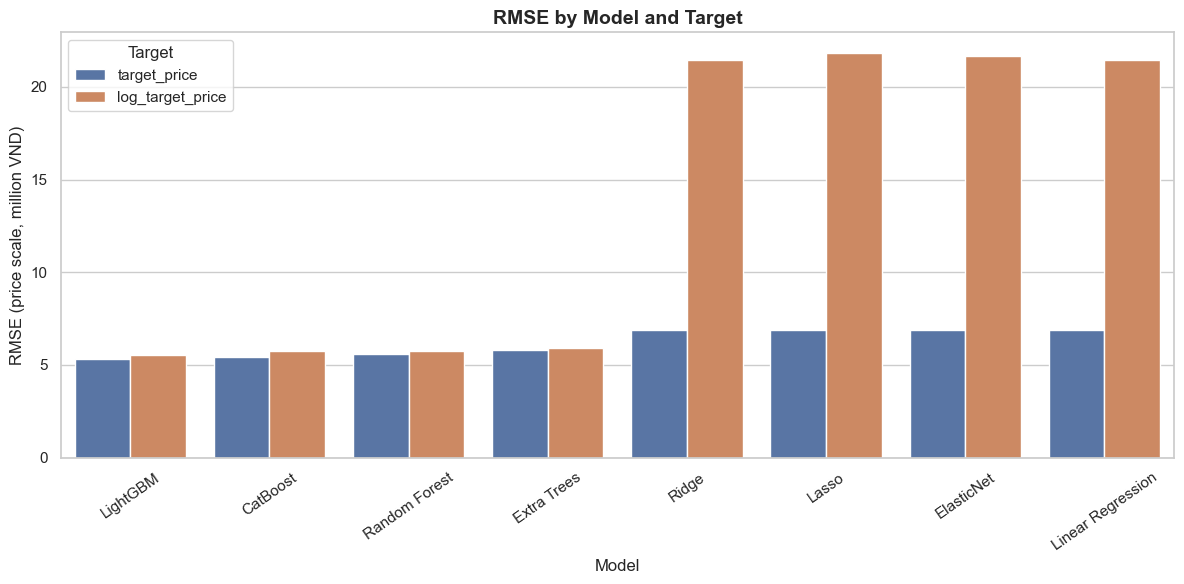

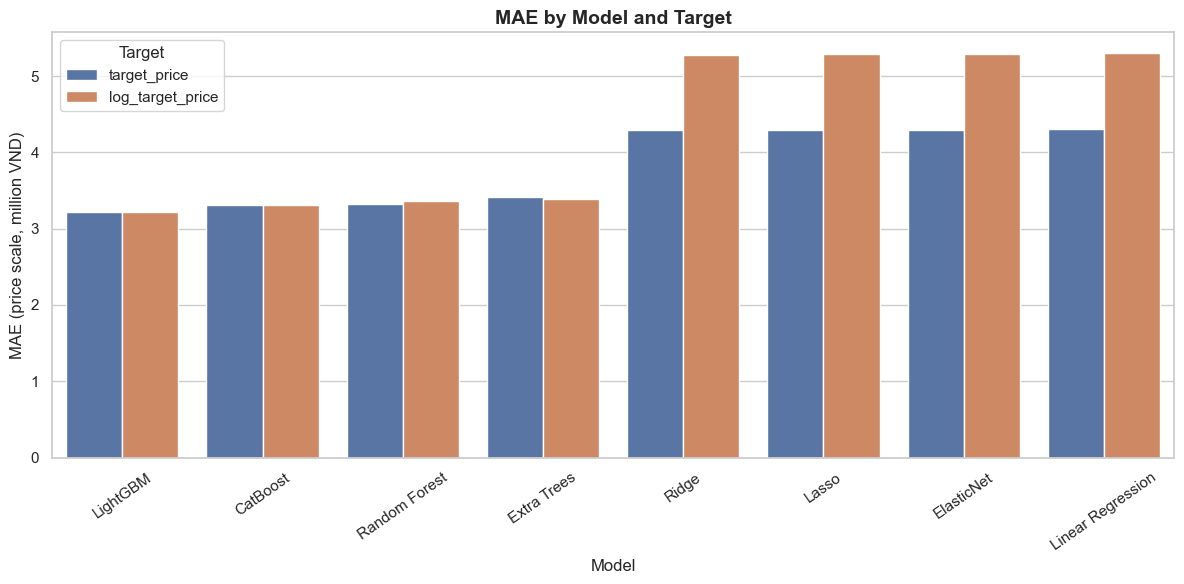

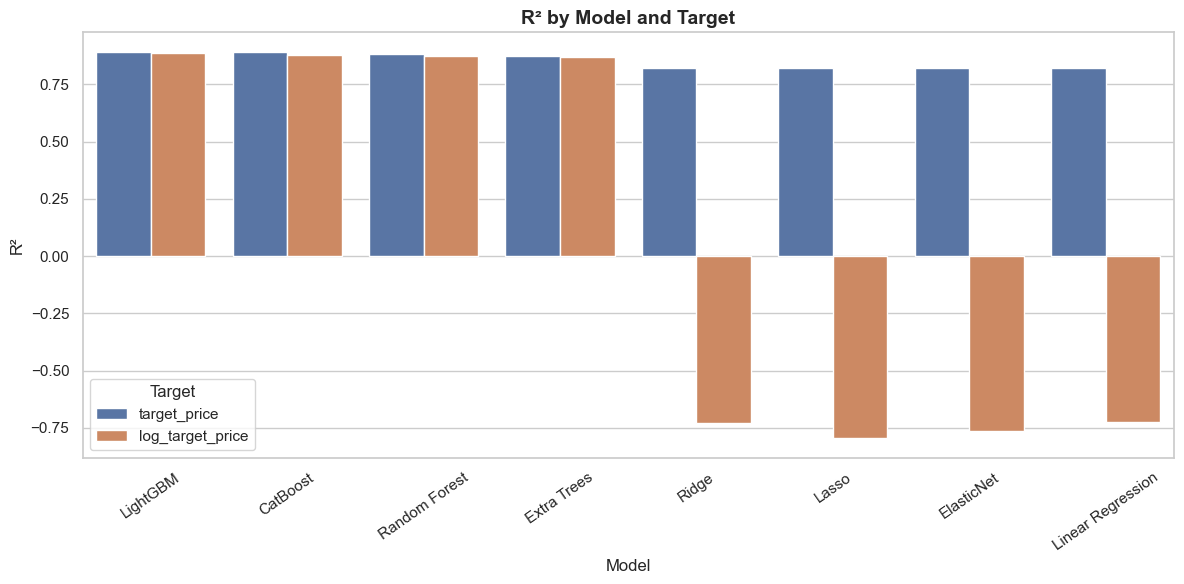

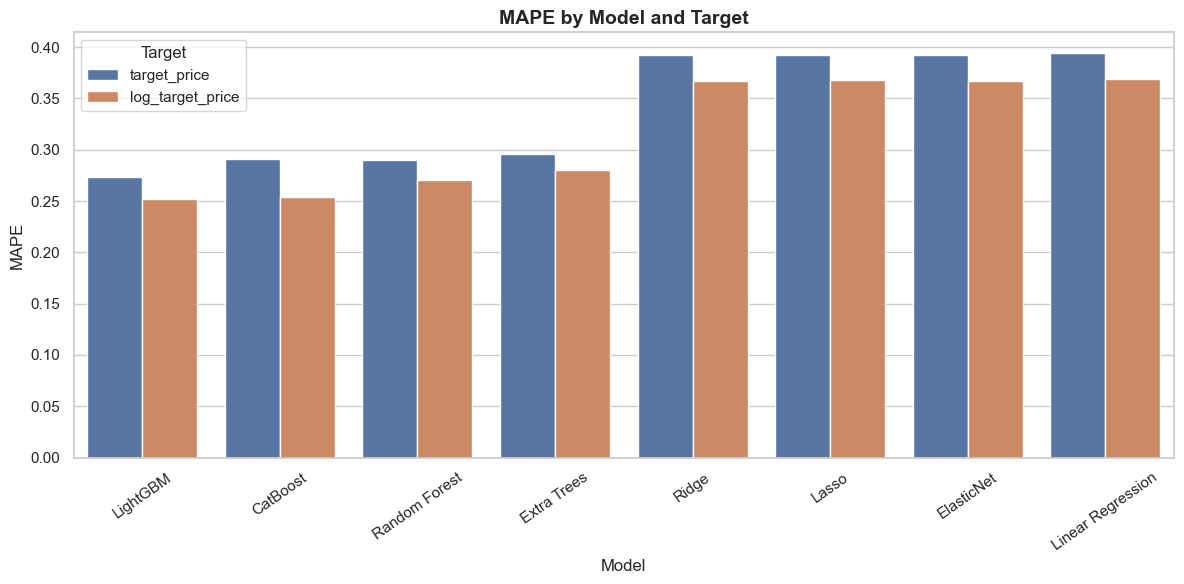

In [11]:
# Consistent model ordering by best RMSE
model_order = (
    metrics_df.groupby('model_name')['rmse'].min()
    .sort_values()
    .index.tolist()
)

target_hue_order = TARGET_ORDER
target_palette = TARGET_PALETTE


def bar_metric(metric: str, ylabel: str, title: str, ascending: bool = True) -> None:
    if metric not in metrics_df.columns:
        print(f'Metric {metric} not available, skipping.')
        return
    fig, ax = plt.subplots(figsize=(12, 6))
    plot_df = metrics_df.copy()
    plot_df['model_name'] = pd.Categorical(plot_df['model_name'], categories=model_order, ordered=True)
    plot_df = plot_df.sort_values(['model_name', 'target_used'])
    sns.barplot(
        data=plot_df,
        x='model_name',
        y=metric,
        hue='target_used',
        hue_order=target_hue_order,
        palette=target_palette,
        ax=ax,
    )
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('Model')
    ax.set_ylabel(ylabel)
    ax.tick_params(axis='x', rotation=35)
    ax.legend(title='Target')
    plt.tight_layout()
    plt.savefig(COMPARISON_DIR / f'{metric}_by_model_and_target.png', dpi=160, bbox_inches='tight')
    plt.show()


# Bar charts. Error metrics are on the original price scale, in million VND.
bar_metric('rmse', 'RMSE (price scale, million VND)', 'RMSE by Model and Target')
bar_metric('mae', 'MAE (price scale, million VND)', 'MAE by Model and Target')
bar_metric('r2', 'R²', 'R² by Model and Target', ascending=False)
if 'mape' in metrics_df.columns:
    bar_metric('mape', 'MAPE', 'MAPE by Model and Target')


### Metric Comparison by Model and Target

These charts compare each model under direct `target_price` and `log_target_price`, with all metrics computed on the original price scale.

For **RMSE**, direct `target_price` wins for every model. The gap is small for tree-based models and catastrophic for linear models trained on `log_target_price`.

For **MAE**, `log_target_price` helps LightGBM, CatBoost, and Extra Trees, but direct price wins for Random Forest and all linear models. The best MAE overall is LightGBM with `log_target_price`, only slightly ahead of LightGBM with `target_price`.

For **R²**, direct price wins across the board. The log-target linear models have negative R² and should be treated as failed configurations.

For **MAPE**, `log_target_price` wins for every model, confirming that the transformation mainly improves relative-error behavior.

Overall, numeric encoding strengthens the case for direct `target_price` when RMSE/R² matter, while `log_target_price` remains useful only for MAE/MAPE in selected tree-based models.


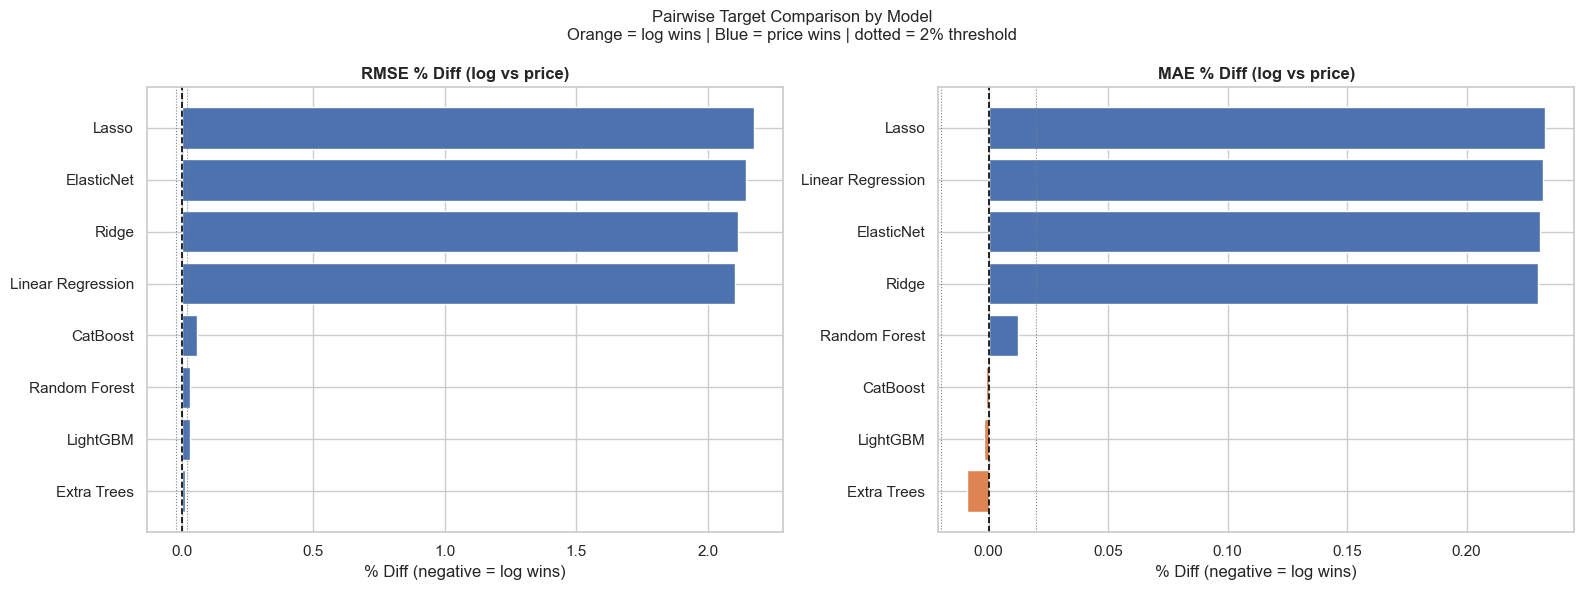

In [12]:
# ── Pairwise percentage-difference plots ──────────────────────────────────────
if not pairwise_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    for ax, metric_col, title in [
        (axes[0], 'rmse_pct_diff_log_vs_price', 'RMSE % Diff (log vs price)'),
        (axes[1], 'mae_pct_diff_log_vs_price',  'MAE % Diff (log vs price)'),
    ]:
        colors = ['#DD8452' if v < 0 else '#4C72B0'
                  for v in pairwise_df[metric_col]]
        sorted_pw = pairwise_df.sort_values(metric_col)
        ax.barh(sorted_pw['model_name'], sorted_pw[metric_col],
                color=['#DD8452' if v < 0 else '#4C72B0'
                       for v in sorted_pw[metric_col]])
        ax.axvline(0, color='black', linewidth=1.2, linestyle='--')
        ax.axvline(-CLOSE_WIN_THRESHOLD, color='gray', linewidth=0.8, linestyle=':')
        ax.axvline( CLOSE_WIN_THRESHOLD, color='gray', linewidth=0.8, linestyle=':')
        ax.set_title(title, fontweight='bold')
        ax.set_xlabel('% Diff (negative = log wins)')

    plt.suptitle('Pairwise Target Comparison by Model\n'
                 'Orange = log wins | Blue = price wins | dotted = 2% threshold',
                 fontsize=12)
    plt.tight_layout()
    plt.savefig(COMPARISON_DIR / 'pairwise_pct_diff_by_model.png', dpi=160, bbox_inches='tight')
    plt.show()

### Pairwise Target Comparison by Model

This chart shows the percentage difference between `log_target_price` and `target_price` for each model. Negative values mean log-target is better; positive values mean direct price is better.

For **RMSE**, every model favors direct `target_price`. The linear models show extreme degradation under log-target, while tree-based models show smaller but still consistent RMSE losses.

For **MAE**, the tree-based results are mixed: LightGBM, CatBoost, and Extra Trees improve with log-target, while Random Forest favors direct price. The linear models again favor direct price.

The chart confirms that numeric encoding creates a sharper trade-off than level encoding: log-target helps MAPE and sometimes MAE, but it does not improve RMSE for any model.


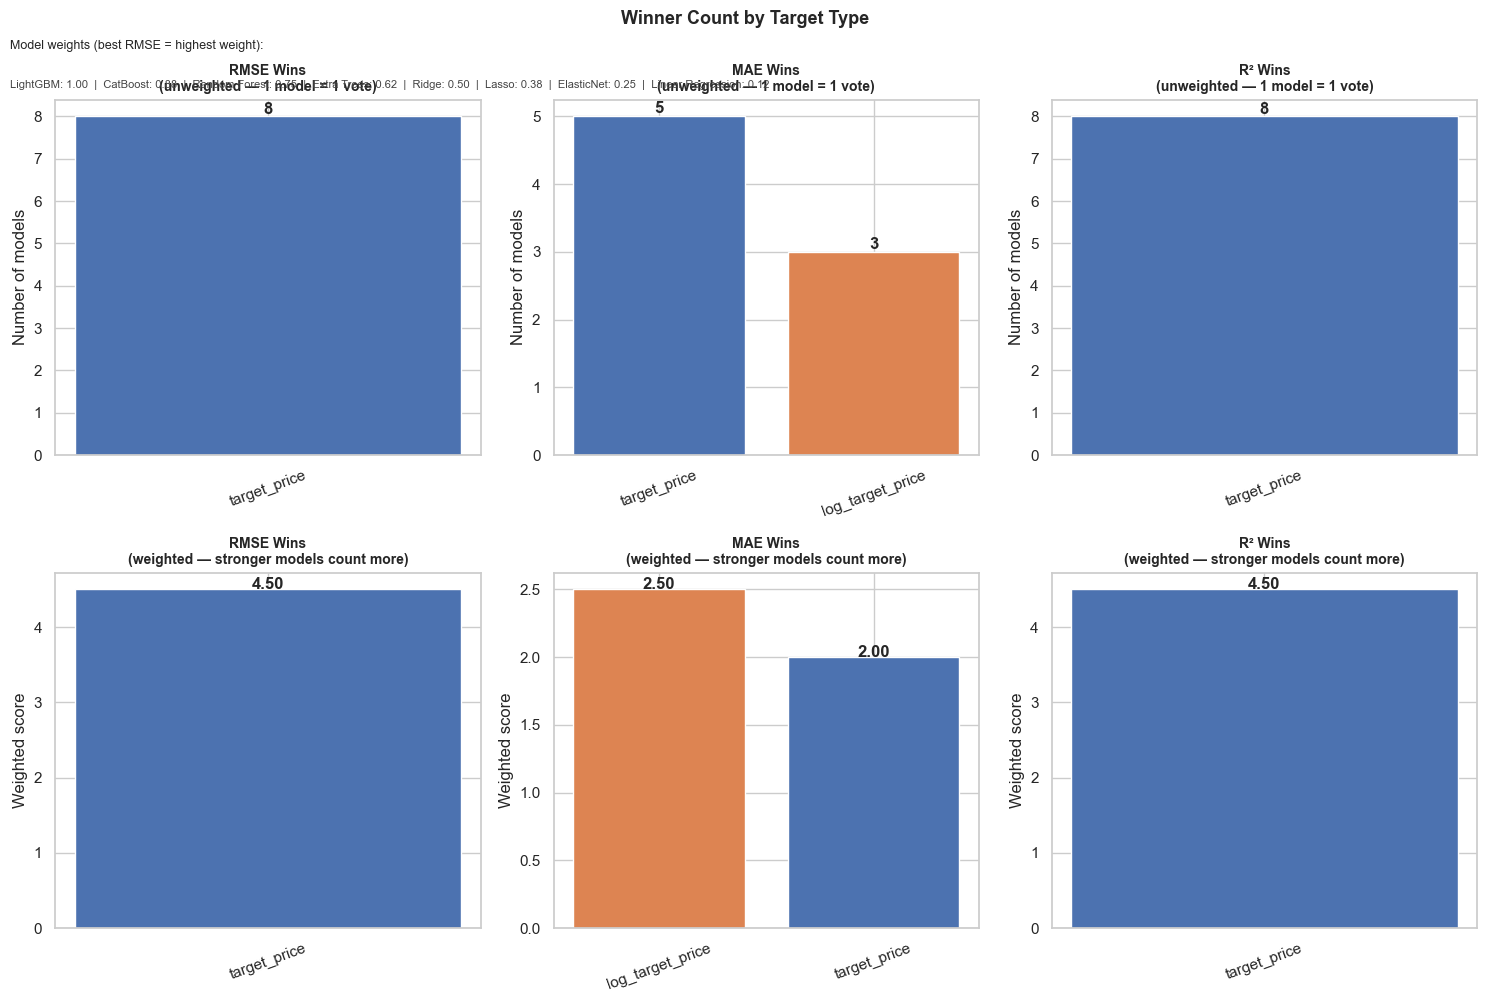

In [13]:
# ── Winner count chart (unweighted + weighted by model strength) ──────────────
if not pairwise_df.empty:
    # Compute model weights (same as cell 21)
    model_best_rmse = metrics_df.groupby('model_name')['rmse'].min().sort_values()
    n_w = len(model_best_rmse)
    model_weight = {m: (n_w - rank) / n_w
                    for rank, m in enumerate(model_best_rmse.index)}

    def weighted_wins(col):
        return (
            pairwise_df[['model_name', col]]
            .assign(w=pairwise_df['model_name'].map(model_weight))
            .groupby(col)['w'].sum()
        )

    fig, axes = plt.subplots(2, 3, figsize=(15, 10))

    metrics_to_plot = [
        ('rmse_winner', 'RMSE Wins'),
        ('mae_winner',  'MAE Wins'),
        ('r2_winner',   'R\u00b2 Wins'),
    ]

    def _bar_colors(index):
        return [
            '#DD8452' if idx == 'log_target_price' else
            '#4C72B0' if idx == 'target_price' else '#888888'
            for idx in index
        ]

    # Row 0: unweighted counts
    for ax, (col, title) in zip(axes[0], metrics_to_plot):
        counts = pairwise_df[col].value_counts()
        ax.bar(counts.index, counts.values,
               color=_bar_colors(counts.index), edgecolor='white')
        ax.set_title(f'{title}\n(unweighted — 1 model = 1 vote)',
                     fontweight='bold', fontsize=10)
        ax.set_ylabel('Number of models')
        ax.tick_params(axis='x', rotation=20)
        for i, v in enumerate(counts.values):
            ax.text(i, v + 0.05, str(v), ha='center', fontweight='bold')

    # Row 1: weighted by model strength
    for ax, (col, title) in zip(axes[1], metrics_to_plot):
        ww = weighted_wins(col).sort_values(ascending=False)
        ax.bar(ww.index, ww.values,
               color=_bar_colors(ww.index), edgecolor='white')
        ax.set_title(f'{title}\n(weighted — stronger models count more)',
                     fontweight='bold', fontsize=10)
        ax.set_ylabel('Weighted score')
        ax.tick_params(axis='x', rotation=20)
        for i, v in enumerate(ww.values):
            ax.text(i, v + 0.005, f'{v:.2f}', ha='center', fontweight='bold')

    fig.text(0.01, 0.97, 'Model weights (best RMSE = highest weight):',
             fontsize=9, va='top')
    weight_str = '  |  '.join(
        f'{m}: {w:.2f}' for m, w in
        sorted(model_weight.items(), key=lambda x: -x[1])
    )
    fig.text(0.01, 0.93, weight_str, fontsize=8, va='top', color='#444444')

    plt.suptitle('Winner Count by Target Type', fontsize=13, fontweight='bold', y=1.0)
    plt.tight_layout()
    plt.savefig(COMPARISON_DIR / 'winner_count_by_target.png', dpi=160, bbox_inches='tight')
    plt.show()


### Winner Count by Target Type

The top row shows unweighted counts. The bottom row shows weighted counts, where stronger models receive more influence.

**RMSE wins:** direct `target_price` wins 8/8 models, with a weighted score of 4.50/4.50. This is the clearest signal in the numeric notebook.

**MAE wins:** direct price wins 5/8 models, while `log_target_price` wins 3/8. The weighted MAE result slightly favors log-target (2.50 vs 2.00) because the log-target wins include strong models such as LightGBM and CatBoost.

**MAPE wins:** log-target wins across the board, so it remains useful for relative error.

The correct interpretation is not that log-target is generally better. In numeric encoding, direct price is the primary strategy for RMSE/R², while log-target is a secondary option for selected tree-based models when MAE/MAPE is prioritized.


## 10. Prediction-Level Comparison

Using the saved `test_predictions.csv`, we build a long-format error dataframe for the best price model and the best log-price model, then generate diagnostic plots.

In [14]:
if predictions_raw is not None:
    pred_df = predictions_raw.copy()
    print('Prediction columns:', pred_df.columns.tolist())
    display(pred_df.head())
else:
    print('No predictions file loaded. Skipping prediction-level analysis.')
    pred_df = None

Prediction columns: ['sample_id', 'y_true_price', 'pred_LinearRegression_target_price', 'pred_LinearRegression_log_target_price', 'pred_Ridge_target_price', 'pred_Ridge_log_target_price', 'pred_Lasso_target_price', 'pred_Lasso_log_target_price', 'pred_ElasticNet_target_price', 'pred_ElasticNet_log_target_price', 'pred_RandomForest_target_price', 'pred_RandomForest_log_target_price', 'pred_ExtraTrees_target_price', 'pred_ExtraTrees_log_target_price', 'pred_LightGBM_target_price', 'pred_LightGBM_log_target_price', 'pred_CatBoost_target_price', 'pred_CatBoost_log_target_price']


,sample_id,y_true_price,pred_LinearRegression_target_price,pred_LinearRegression_log_target_price,pred_Ridge_target_price,pred_Ridge_log_target_price,pred_Lasso_target_price,pred_Lasso_log_target_price,pred_ElasticNet_target_price,pred_ElasticNet_log_target_price,pred_RandomForest_target_price,pred_RandomForest_log_target_price,pred_ExtraTrees_target_price,pred_ExtraTrees_log_target_price,pred_LightGBM_target_price,pred_LightGBM_log_target_price,pred_CatBoost_target_price,pred_CatBoost_log_target_price
0,3909,5.5000,4.8707,5.0810,5.0816,4.9399,5.0704,5.0358,5.0665,4.9897,4.6633,4.1106,4.7393,5.1778,3.7060,3.5681,4.3277,3.8327
1,6004,37.4990,22.5133,20.9212,22.7142,20.9117,22.6888,20.7552,22.6843,20.8199,30.9067,28.9058,32.4439,31.6378,28.5706,30.3664,27.9014,28.0176
2,1768,27.4900,15.5426,13.1802,15.4753,13.0721,15.4822,12.8115,15.4787,12.9277,21.3259,19.5354,21.2413,19.3984,19.6340,18.2145,17.3898,16.6207
3,3360,7.8000,6.8942,6.4143,6.6530,6.1988,6.6555,6.1620,6.6491,6.1789,8.7528,8.4264,10.0000,10.0000,8.0080,8.0429,7.4755,7.5056
4,4700,12.9900,10.3932,7.6820,10.2927,7.6271,10.2967,7.7830,10.3003,7.7143,11.5081,11.4461,11.6000,11.5964,11.1778,10.9470,10.8644,11.0274


In [15]:
# ── Identify actual price column ──────────────────────────────────────────────
long_format_rows = []
errors_long_df = None

if pred_df is not None:
    # Detect the actual price column
    # IMPORTANT: y_true_price must be checked before fallback columns like sample_id
    actual_col_candidates = [
        'y_true_price',
        'actual_price',
        'target_price',
        'y_true',
        'price'
    ]

    actual_col = next((c for c in actual_col_candidates if c in pred_df.columns), None)

    if actual_col is None:
        # Safer fallback: exclude ID/index-like columns and prediction columns
        non_pred_cols = [
            c for c in pred_df.columns
            if not c.startswith('pred_')
            and c.lower() not in ['sample_id', 'id', 'index', 'row_id']
        ]

        print(f'Could not auto-detect actual column. Candidate non-pred columns: {non_pred_cols}')

        if len(non_pred_cols) == 1:
            actual_col = non_pred_cols[0]
        else:
            raise ValueError(
                "Could not safely detect actual price column. "
                f"Available columns: {list(pred_df.columns)}"
            )

    print(f'Using actual price column: {actual_col}')

    # Identify prediction columns
    pred_cols = [c for c in pred_df.columns if c.startswith('pred_')]
    print(f'Prediction columns found: {pred_cols}')

    if actual_col and pred_cols:
        y_actual = pred_df[actual_col].values

        for col in pred_cols:
            # Infer model_name and target_used from column name
            # Expected pattern: pred_<ModelName>_<target_used>
            col_suffix = col[len('pred_'):]

            if 'log_target_price' in col_suffix:
                target_u = 'log_target_price'
                model_n = col_suffix.replace('_log_target_price', '')
            elif 'target_price' in col_suffix:
                target_u = 'target_price'
                model_n = col_suffix.replace('_target_price', '')
            else:
                target_u = 'unknown'
                model_n = col_suffix

            y_pred_vals = pred_df[col].values
            residuals = y_actual - y_pred_vals
            abs_err = np.abs(residuals)
            ape = np.where(y_actual != 0, abs_err / np.abs(y_actual), np.nan)

            for i in range(len(y_actual)):
                long_format_rows.append({
                    'actual_price': y_actual[i],
                    'predicted_price': y_pred_vals[i],
                    'residual': residuals[i],
                    'absolute_error': abs_err[i],
                    'absolute_percentage_error': ape[i],
                    'model_name': model_n,
                    'target_used': target_u,
                })

        errors_long_df = pd.DataFrame(long_format_rows)

        print(f'\nLong-format error dataframe shape: {errors_long_df.shape}')
        display(errors_long_df.head())

        errors_long_df.to_csv(
            COMPARISON_DIR / 'target_comparison_prediction_errors_long.csv',
            index=False
        )

        print('Saved: target_comparison_prediction_errors_long.csv')
    else:
        print('Cannot build long-format dataframe. Missing actual column or prediction columns.')
else:
    print('Skipping long-format error table (no predictions file).')

Using actual price column: y_true_price
Prediction columns found: ['pred_LinearRegression_target_price', 'pred_LinearRegression_log_target_price', 'pred_Ridge_target_price', 'pred_Ridge_log_target_price', 'pred_Lasso_target_price', 'pred_Lasso_log_target_price', 'pred_ElasticNet_target_price', 'pred_ElasticNet_log_target_price', 'pred_RandomForest_target_price', 'pred_RandomForest_log_target_price', 'pred_ExtraTrees_target_price', 'pred_ExtraTrees_log_target_price', 'pred_LightGBM_target_price', 'pred_LightGBM_log_target_price', 'pred_CatBoost_target_price', 'pred_CatBoost_log_target_price']

Long-format error dataframe shape: (23360, 7)


,actual_price,predicted_price,residual,absolute_error,absolute_percentage_error,model_name,target_used
0,5.5000,4.8707,0.6293,0.6293,0.1144,LinearRegression,target_price
1,37.4990,22.5133,14.9857,14.9857,0.3996,LinearRegression,target_price
2,27.4900,15.5426,11.9474,11.9474,0.4346,LinearRegression,target_price
3,7.8000,6.8942,0.9058,0.9058,0.1161,LinearRegression,target_price
4,12.9900,10.3932,2.5968,2.5968,0.1999,LinearRegression,target_price


Saved: target_comparison_prediction_errors_long.csv


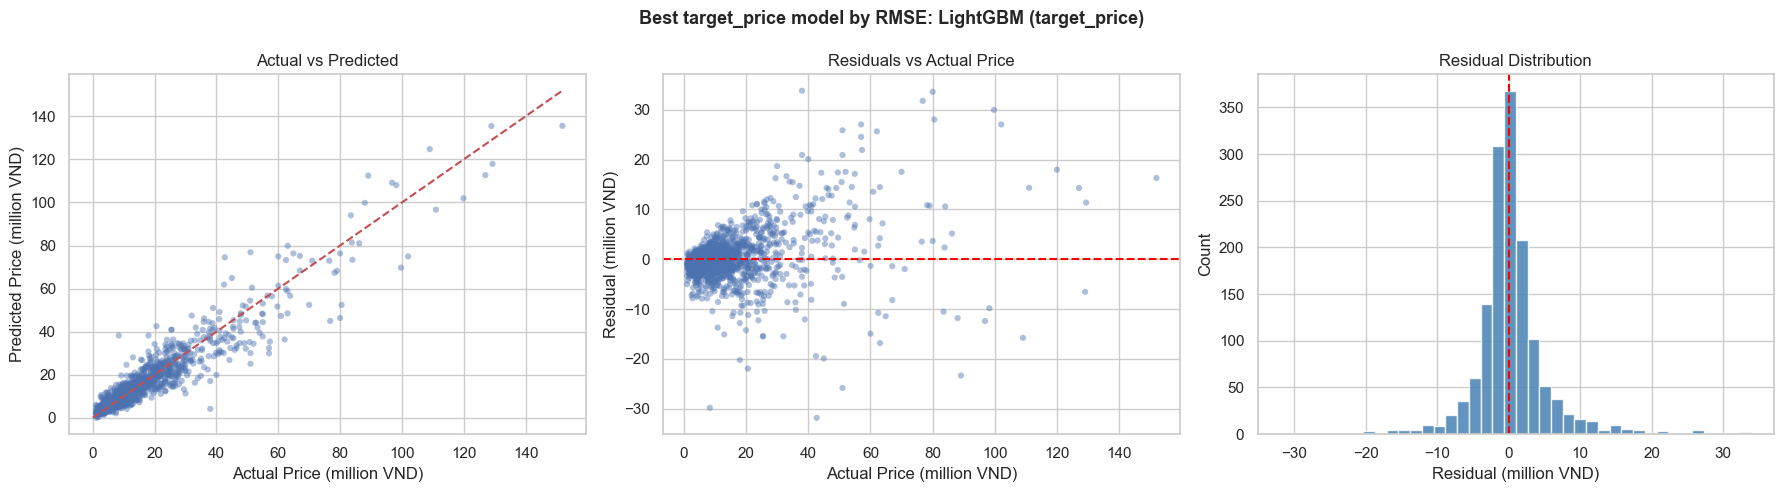

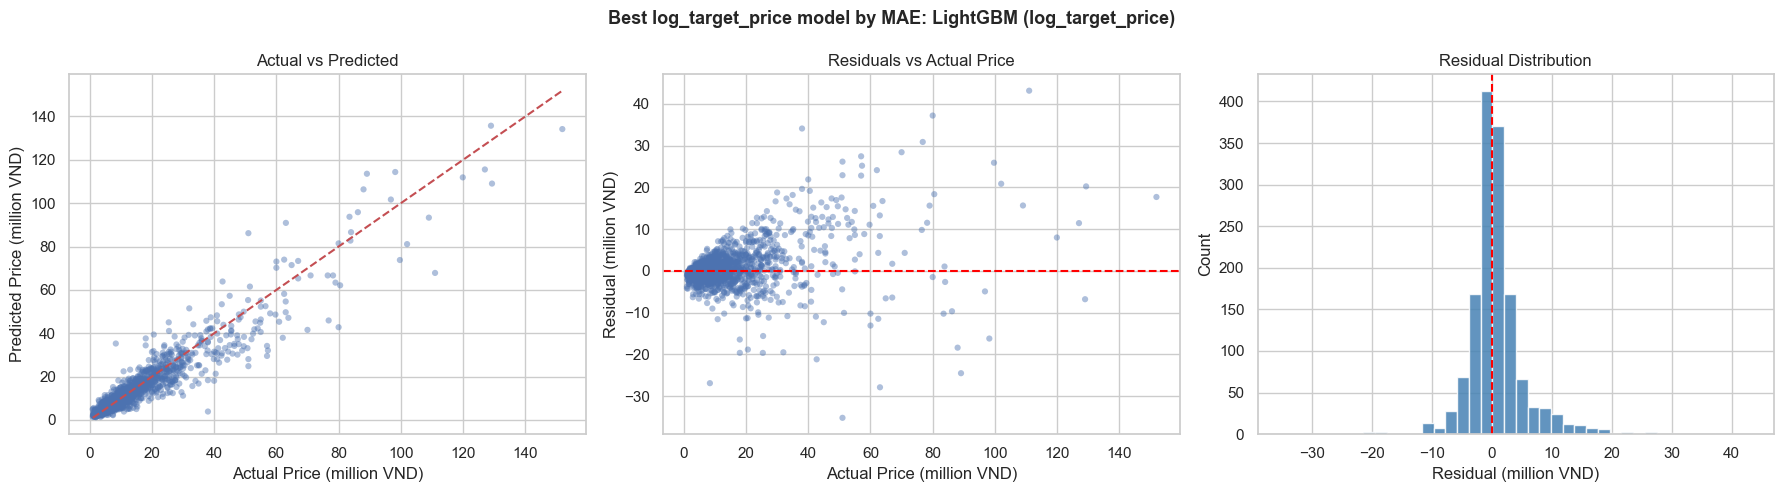

In [16]:
# Diagnostic plots for best direct-price and best log_target_price models
if errors_long_df is not None and not errors_long_df.empty:
    best_price_row = price_metrics_df.sort_values('rmse').iloc[0]
    best_log_target_row = log_target_metrics_df.sort_values('mae').iloc[0]

    def to_model_col_format(name):
        return name.replace(' ', '')

    diagnostic_models = [
        (best_price_row, 'Best target_price model by RMSE'),
        (best_log_target_row, 'Best log_target_price model by MAE'),
    ]

    for row, label in diagnostic_models:
        model_n = row['model_name']
        target_u = row['target_used']
        subset = errors_long_df[
            (errors_long_df['target_used'] == target_u) &
            (
                errors_long_df['model_name'].str.lower().str.replace(' ', '') ==
                to_model_col_format(model_n).lower()
            )
        ]

        if subset.empty:
            print(f'No predictions found for {model_n} ({target_u}). Skipping plots.')
            continue

        y_t = subset['actual_price'].values
        y_p = subset['predicted_price'].values
        res = subset['residual'].values

        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        fig.suptitle(f'{label}: {model_n} ({target_u})', fontsize=13, fontweight='bold')

        ax = axes[0]
        ax.scatter(y_t, y_p, alpha=0.45, edgecolors='none', s=20)
        mn, mx = min(y_t.min(), y_p.min()), max(y_t.max(), y_p.max())
        ax.plot([mn, mx], [mn, mx], 'r--', lw=1.5)
        ax.set_title('Actual vs Predicted')
        ax.set_xlabel('Actual Price (million VND)')
        ax.set_ylabel('Predicted Price (million VND)')

        ax = axes[1]
        ax.scatter(y_t, res, alpha=0.45, edgecolors='none', s=20)
        ax.axhline(0, color='red', lw=1.5, linestyle='--')
        ax.set_title('Residuals vs Actual Price')
        ax.set_xlabel('Actual Price (million VND)')
        ax.set_ylabel('Residual (million VND)')

        ax = axes[2]
        ax.hist(res, bins=40, edgecolor='white', color='steelblue', alpha=0.85)
        ax.axvline(0, color='red', lw=1.5, linestyle='--')
        ax.set_title('Residual Distribution')
        ax.set_xlabel('Residual (million VND)')
        ax.set_ylabel('Count')

        plt.tight_layout()
        safe_name = f"{to_model_col_format(model_n)}_{target_u}"
        plt.savefig(COMPARISON_DIR / f'diagnostic_{safe_name}.png', dpi=160, bbox_inches='tight')
        plt.show()
else:
    print('Skipping diagnostic plots (no long-format error dataframe).')


### Best Model Diagnostic Comparison

These diagnostic plots should be interpreted with the updated winners in mind: the best direct-price model is **LightGBM with `target_price`**, and the best log-target model by MAE is **LightGBM with `log_target_price`**.

Both LightGBM variants are expected to track actual prices well in the low-to-mid range, with wider residuals for expensive laptops. The log-target version should show better typical and percentage-based error, while the direct-price version should better control RMSE.

Because the MAE difference between the two LightGBM variants is very small, the diagnostic plots are mainly useful for checking bias and high-price behavior. The metric table remains the main basis for final selection.

Overall, the diagnostics support **LightGBM with `target_price`** as the balanced choice and **LightGBM with `log_target_price`** as the MAE/MAPE alternative.


## 11. Segment-Level Error Analysis

We split the test set into four price segments using quantile-based bins:
- **Low**: 0–25th percentile
- **Mid**: 25th–50th percentile
- **High**: 50th–75th percentile
- **Premium**: 75th–100th percentile

Segment-level analysis reveals whether log-transform helps more in lower price ranges and whether it degrades accuracy for premium laptops.

In [17]:
segment_df = None

if errors_long_df is not None and not errors_long_df.empty:
    # Create segments based on actual_price quantiles
    q25, q50, q75 = np.quantile(errors_long_df['actual_price'].unique(), [0.25, 0.5, 0.75])
    print(f'Price quantiles: Q25={q25:,.0f}  Q50={q50:,.0f}  Q75={q75:,.0f}')

    def assign_segment(price):
        if price <= q25:
            return 'Low'
        elif price <= q50:
            return 'Mid'
        elif price <= q75:
            return 'High'
        else:
            return 'Premium'

    errors_long_df['price_segment'] = errors_long_df['actual_price'].apply(assign_segment)
    errors_long_df['price_segment'] = pd.Categorical(
        errors_long_df['price_segment'],
        categories=['Low', 'Mid', 'High', 'Premium'],
        ordered=True
    )

    # Segment-level metrics
    seg_records = []
    for (model_n, target_u, segment), grp in errors_long_df.groupby(
        ['model_name', 'target_used', 'price_segment'], observed=True
    ):
        yt = grp['actual_price'].values
        yp = grp['predicted_price'].values
        res = grp['residual'].values

        seg_records.append({
            'model_name'           : model_n,
            'target_used'          : target_u,
            'price_segment'        : segment,
            'count'                : len(yt),
            'mae'                  : mean_absolute_error(yt, yp),
            'rmse'                 : root_mean_squared_error(yt, yp),
            'mape'                 : mean_absolute_percentage_error(yt, yp),
            'median_absolute_error': median_absolute_error(yt, yp),
            'mean_residual'        : res.mean(),
        })

    segment_df = pd.DataFrame(seg_records)
    display(segment_df.sort_values(['model_name', 'target_used', 'price_segment']).head(30))

    segment_df.to_csv(
        COMPARISON_DIR / 'target_comparison_error_by_price_segment.csv', index=False
    )
    print('Saved: target_comparison_error_by_price_segment.csv')
else:
    print('Skipping segment analysis (no long-format error data).')

Price quantiles: Q25=8  Q50=17  Q75=29


,model_name,target_used,price_segment,count,mae,rmse,mape,median_absolute_error,mean_residual
2,CatBoost,log_target_price,High,252,4.4531,5.8238,0.2009,3.3588,1.2161
0,CatBoost,log_target_price,Low,597,1.3475,1.9469,0.3240,0.9638,-0.4809
1,CatBoost,log_target_price,Mid,437,2.3679,3.0342,0.2031,1.8857,0.3630
3,CatBoost,log_target_price,Premium,174,10.7219,13.7844,0.2215,9.5014,7.7024
6,CatBoost,target_price,High,252,4.2677,5.5408,0.1941,3.5055,0.4264
4,CatBoost,target_price,Low,597,1.6721,2.4104,0.4137,1.2219,-0.8974
5,CatBoost,target_price,Mid,437,2.5126,3.2779,0.2166,1.9524,-0.1999
7,CatBoost,target_price,Premium,174,9.5483,12.4311,0.1986,7.2445,6.1641
10,ElasticNet,log_target_price,High,252,6.0569,7.5815,0.2745,5.0049,2.3119
8,ElasticNet,log_target_price,Low,597,1.8286,2.4187,0.4977,1.4554,-1.0734


Saved: target_comparison_error_by_price_segment.csv


### Price Segment Error Analysis

The price quantiles divide the test set into four segments:

- Low: lower-price laptops
- Mid: lower-middle price laptops
- High: upper-middle price laptops
- Premium: the most expensive laptops

For CatBoost, `log_target_price` is better in the Low and Mid segments, while direct `target_price` is better in the High and Premium segments. This means log-target does not dominate across the full price range.

The Premium segment is still the hardest segment in absolute-error terms. Direct-price CatBoost has lower MAE, RMSE, and MAPE than log-target CatBoost for Premium laptops, so direct-price models remain important when high-price accuracy matters.

The residual pattern still shows compression toward the center of the price distribution: lower-price laptops tend to be overpredicted, while premium laptops tend to be underpredicted.


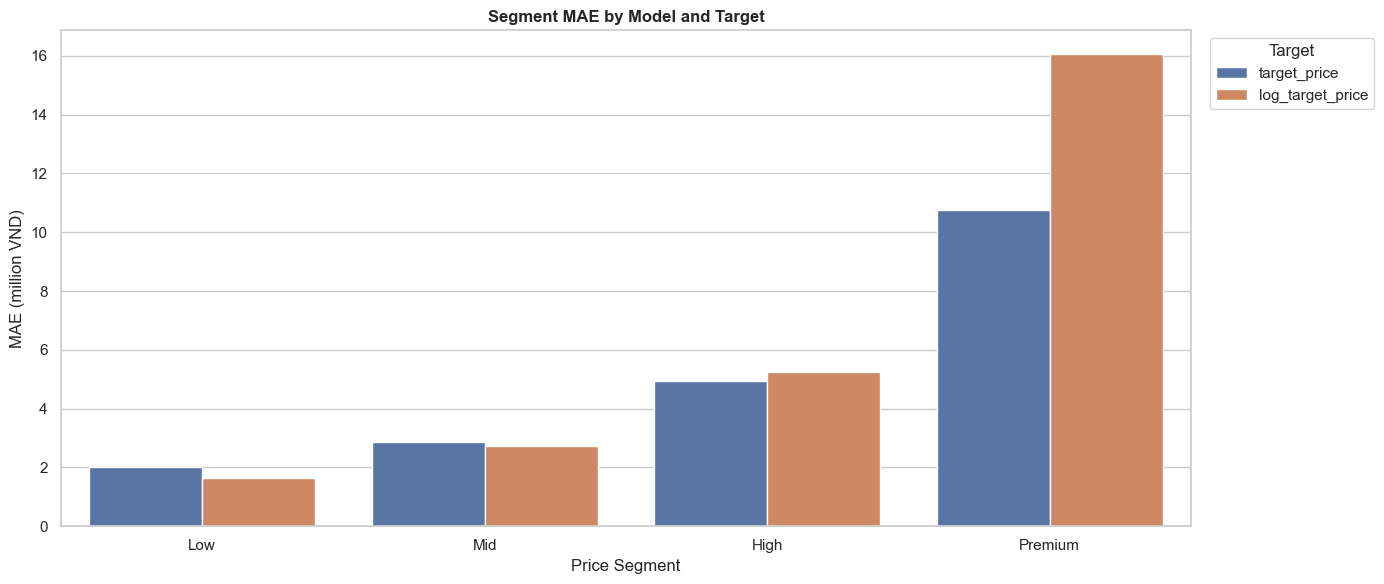

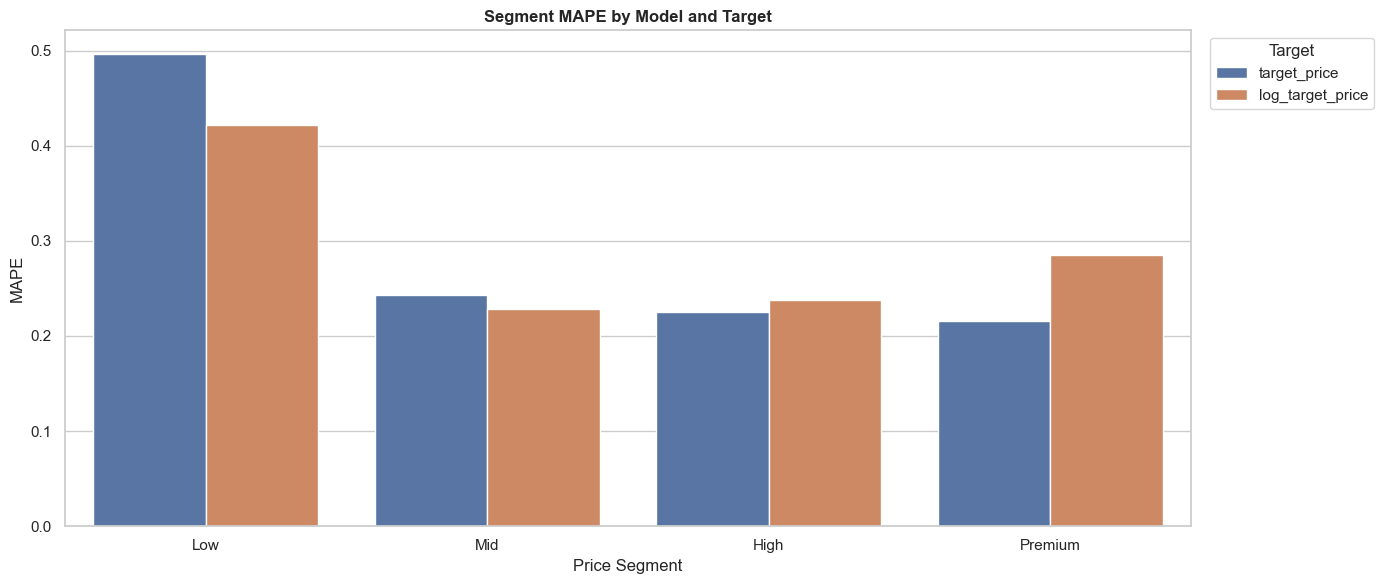

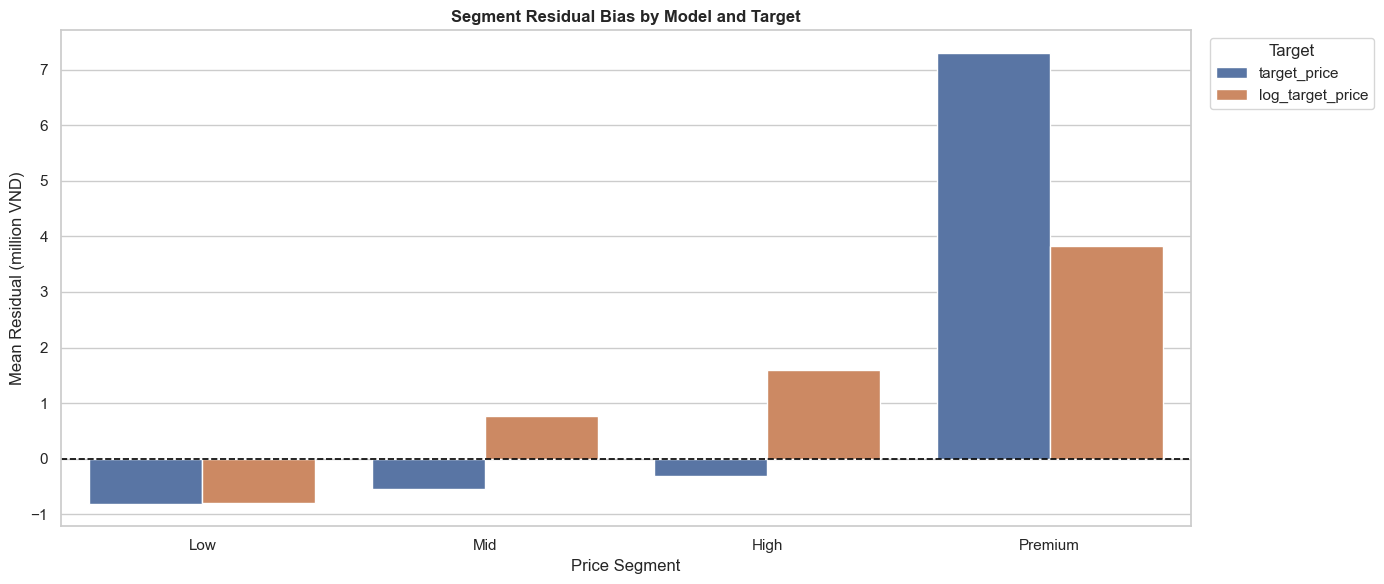

In [18]:
# Segment-level plots
if segment_df is not None and not segment_df.empty:
    segment_df['target_used'] = pd.Categorical(
        segment_df['target_used'],
        categories=TARGET_ORDER,
        ordered=True,
    )

    for metric, ylabel, title in [
        ('mae', 'MAE (million VND)', 'Segment MAE by Model and Target'),
        ('mape', 'MAPE', 'Segment MAPE by Model and Target'),
        ('mean_residual', 'Mean Residual (million VND)', 'Segment Residual Bias by Model and Target'),
    ]:
        fig, ax = plt.subplots(figsize=(14, 6))
        plot_df = segment_df.sort_values(['model_name', 'target_used'])
        sns.barplot(
            data=plot_df,
            x='price_segment',
            y=metric,
            hue='target_used',
            hue_order=target_hue_order,
            palette=target_palette,
            ax=ax,
            errorbar=None,
        )
        ax.set_title(title, fontweight='bold')
        ax.set_xlabel('Price Segment')
        ax.set_ylabel(ylabel)
        if metric == 'mean_residual':
            ax.axhline(0, color='black', lw=1.2, linestyle='--')
        ax.tick_params(axis='x', rotation=0)
        ax.legend(title='Target', bbox_to_anchor=(1.01, 1), loc='upper left')
        plt.tight_layout()
        plt.savefig(COMPARISON_DIR / f'segment_{metric}_by_model_target.png',
                    dpi=160, bbox_inches='tight')
        plt.show()
else:
    print('Skipping segment plots.')


### Segment-Level Error Analysis by Model and Target

These charts compare model behavior across Low, Mid, High, and Premium price segments.

Segment MAE generally increases with price, so Premium laptops remain the hardest to predict in absolute terms. The tree-based models are consistently stronger than the linear models, especially because numeric log-target linear models fail badly.

For CatBoost, the segment-level result is mixed: log-target helps Low and Mid, while direct price is better in High and Premium. This supports the final conclusion that target selection depends on whether the priority is common-price accuracy or high-price error control.

The MAPE chart usually favors log-target because it optimizes relative differences. The residual-bias chart should be used to monitor systematic overprediction in low-price items and underprediction in premium items.


## 12A. Linear `log_target_price` Outlier Check

The numeric-encoded notebook has a specific failure mode: linear models trained on `log_target_price` produce very large price-scale errors after inverse transformation. This section inspects the worst rows for those configurations.

The important diagnostic is not only the final RMSE. A small overprediction in log space can become a very large overprediction after `np.expm1`, so the notebook checks the implied log prediction from the saved price-scale prediction and flags rows with extreme absolute error.

The saved prediction file only contains inverse-transformed price predictions, so the raw `y_pred_log` values cannot be inspected directly here. The notebook therefore reconstructs an implied `log1p(predicted_price)` as a proxy and verifies that the configured transform is `log1p`, whose inverse should be `np.expm1`.


In [19]:
# Inspect unstable linear + log_target_price predictions on the price scale
linear_models = {'LinearRegression', 'Linear Regression', 'Ridge', 'Lasso', 'ElasticNet'}
linear_log_outliers_df = pd.DataFrame()
print(f'Configured log transform: {LOG_TRANSFORM}; expected inverse for log1p is np.expm1.')

if errors_long_df is not None and not errors_long_df.empty:
    linear_log_df = errors_long_df[
        (errors_long_df['target_used'] == 'log_target_price') &
        (errors_long_df['model_name'].isin(linear_models))
    ].copy()

    if linear_log_df.empty:
        print('No linear + log_target_price rows found in errors_long_df.')
    else:
        linear_log_df['implied_pred_log1p'] = np.where(
            linear_log_df['predicted_price'] > -1,
            np.log1p(linear_log_df['predicted_price']),
            np.nan,
        )
        linear_log_df['actual_log1p'] = np.where(
            linear_log_df['actual_price'] > -1,
            np.log1p(linear_log_df['actual_price']),
            np.nan,
        )
        linear_log_df['log_error_implied'] = (
            linear_log_df['implied_pred_log1p'] - linear_log_df['actual_log1p']
        )

        top_cols = [
            'model_name',
            'target_used',
            'actual_price',
            'predicted_price',
            'absolute_error',
            'absolute_percentage_error',
            'actual_log1p',
            'implied_pred_log1p',
            'log_error_implied',
        ]
        linear_log_outliers_df = (
            linear_log_df.sort_values('absolute_error', ascending=False)
            .head(20)
            .reset_index(drop=True)
        )

        print('=== Worst linear + log_target_price rows by absolute error ===')
        display(linear_log_outliers_df[top_cols])

        summary_cols = ['rmse', 'mae', 'r2']
        if 'max_error' in metrics_df.columns:
            summary_cols.append('max_error')
        linear_log_metric_summary = metrics_df[
            (metrics_df['target_used'] == 'log_target_price') &
            (metrics_df['model_name'].isin(['Linear Regression', 'Ridge', 'Lasso', 'ElasticNet']))
        ][['model_name', 'target_used'] + summary_cols].sort_values('rmse')

        print('\n=== Linear + log_target_price metric summary ===')
        display(linear_log_metric_summary)

        linear_log_outliers_df.to_csv(
            COMPARISON_DIR / 'linear_log_target_outlier_check.csv',
            index=False,
        )
        print('Saved: linear_log_target_outlier_check.csv')
else:
    print('Skipping outlier check because errors_long_df is unavailable.')


Configured log transform: log1p; expected inverse for log1p is np.expm1.
=== Worst linear + log_target_price rows by absolute error ===


,model_name,target_used,actual_price,predicted_price,absolute_error,absolute_percentage_error,actual_log1p,implied_pred_log1p,log_error_implied
0,Lasso,log_target_price,151.8900,826.4886,674.5986,4.4414,5.0297,6.7184,1.6887
1,ElasticNet,log_target_price,151.8900,820.1593,668.2693,4.3997,5.0297,6.7107,1.6810
2,Ridge,log_target_price,151.8900,813.7200,661.8300,4.3573,5.0297,6.7028,1.6731
3,LinearRegression,log_target_price,151.8900,810.3692,658.4792,4.3352,5.0297,6.6987,1.6690
4,Lasso,log_target_price,129.2900,456.8905,327.6005,2.5338,4.8698,6.1266,1.2569
5,LinearRegression,log_target_price,129.2900,456.2530,326.9630,2.5289,4.8698,6.1252,1.2555
6,ElasticNet,log_target_price,129.2900,454.9353,325.6453,2.5187,4.8698,6.1224,1.2526
7,Ridge,log_target_price,129.2900,452.0772,322.7872,2.4966,4.8698,6.1161,1.2463
8,Lasso,log_target_price,110.9900,284.8346,173.8446,1.5663,4.7184,5.6554,0.9370
9,ElasticNet,log_target_price,110.9900,277.3971,166.4071,1.4993,4.7184,5.6290,0.9106



=== Linear + log_target_price metric summary ===


,model_name,target_used,rmse,mae,r2,max_error
12,Linear Regression,log_target_price,21.4264,5.3084,-0.7257,658.4792
13,Ridge,log_target_price,21.4393,5.2819,-0.7278,661.8300
14,ElasticNet,log_target_price,21.6508,5.2848,-0.7621,668.2693
15,Lasso,log_target_price,21.8528,5.2943,-0.7951,674.5986


Saved: linear_log_target_outlier_check.csv


## 12. Best Model Selection

We identify top performers by RMSE, MAE, and a balanced rule. If the leading MAE results are within 2%, the model with lower RMSE and then higher R² is selected as the balanced candidate.


In [20]:
best_rmse_row = metrics_df.loc[metrics_df['rmse'].idxmin()]
best_mae_row = metrics_df.loc[metrics_df['mae'].idxmin()]

# Best balanced: MAE-primary, RMSE tiebreak. This keeps the user-facing
# average error objective, but avoids choosing a model with materially worse
# large-error behavior when MAE is effectively tied.
sorted_by_mae = metrics_df.sort_values('mae').reset_index(drop=True)
top1_mae = sorted_by_mae.iloc[0]['mae']
close_mae_candidates = sorted_by_mae[
    (sorted_by_mae['mae'] - top1_mae) / top1_mae <= CLOSE_WIN_THRESHOLD
].copy()

best_balanced_row = close_mae_candidates.sort_values(['rmse', 'r2'], ascending=[True, False]).iloc[0]
tiebreak_note = (
    f'{len(close_mae_candidates)} MAE-leading results are within '
    f'{CLOSE_WIN_THRESHOLD * 100:.0f}%; RMSE then R² used as tiebreakers.'
)

print('=== Best Model by RMSE ===')
print(best_rmse_row[['model_name', 'target_used', 'rmse', 'mae', 'r2']].to_string())
print()
print('=== Best Model by MAE ===')
print(best_mae_row[['model_name', 'target_used', 'rmse', 'mae', 'r2']].to_string())
print()
print('=== Best Balanced Model (primary: MAE, tiebreak: RMSE/R²) ===')
print(best_balanced_row[['model_name', 'target_used', 'rmse', 'mae', 'r2']].to_string())
print(f'Note: {tiebreak_note}')


=== Best Model by RMSE ===
model_name         LightGBM
target_used    target_price
rmse                 5.3365
mae                  3.2246
r2                   0.8930

=== Best Model by MAE ===
model_name             LightGBM
target_used    log_target_price
rmse                     5.5069
mae                      3.2178
r2                       0.8860

=== Best Balanced Model (primary: MAE, tiebreak: RMSE/R²) ===
model_name         LightGBM
target_used    target_price
rmse                 5.3365
mae                  3.2246
r2                   0.8930
Note: 2 MAE-leading results are within 2%; RMSE then R² used as tiebreakers.


### Best Model Selection

**Why MAE as primary metric?** MAE captures typical prediction error and is useful for user-facing price accuracy. However, the notebook applies RMSE as a tiebreaker when the top MAE results are within 2%.

**Best model by RMSE: LightGBM with `target_price`**
- RMSE = 5.3365, MAE = 3.2246, R² = 0.8930

**Best model by MAE: LightGBM with `log_target_price`**
- MAE = 3.2178, RMSE = 5.5069, R² = 0.8860

**Best balanced model: LightGBM with `target_price`**
- The MAE gap between the two LightGBM variants is very small and within the 2% threshold.
- RMSE is then used as the tiebreaker, which favors `target_price`.

CatBoost is still competitive, but it is no longer the best model under the updated numeric metrics.


## 13. Markdown Interpretation and Conclusion

In [21]:
# ── Compute summary statistics for interpretation ─────────────────────────────
avg_rmse_by_target = metrics_df.groupby('target_used')['rmse'].mean()
avg_mae_by_target  = metrics_df.groupby('target_used')['mae'].mean()

log_better_rmse = False
log_better_mae  = False

if 'log_target_price' in avg_rmse_by_target.index and 'target_price' in avg_rmse_by_target.index:
    log_better_rmse = avg_rmse_by_target['log_target_price'] < avg_rmse_by_target['target_price']
    log_better_mae  = avg_mae_by_target['log_target_price']  < avg_mae_by_target['target_price']

n_models_log_wins_rmse = 0
n_models_log_wins_mae  = 0
log_weighted_mae = log_weighted_rmse = total_weight = 0

if not pairwise_df.empty:
    n_models_log_wins_rmse = (pairwise_df['rmse_winner'] == 'log_target_price').sum()
    n_models_log_wins_mae  = (pairwise_df['mae_winner']  == 'log_target_price').sum()
    total_paired = len(pairwise_df)

    # Weighted wins
    model_best_rmse = metrics_df.groupby('model_name')['rmse'].min().sort_values()
    n_w = len(model_best_rmse)
    model_weight = {m: (n_w - rank) / n_w
                    for rank, m in enumerate(model_best_rmse.index)}
    total_weight = sum(model_weight.values())

    log_weighted_mae  = sum(model_weight[r['model_name']] for _, r in pairwise_df.iterrows()
                            if r['mae_winner']  == 'log_target_price')
    log_weighted_rmse = sum(model_weight[r['model_name']] for _, r in pairwise_df.iterrows()
                            if r['rmse_winner'] == 'log_target_price')
else:
    total_paired = 0

# ── Print interpretation ──────────────────────────────────────────────────────
print('=' * 70)
print('INTERPRETATION SUMMARY')
print('=' * 70)
print()
print(f'Best individual model by RMSE    : {best_rmse_row["model_name"]} '
      f'({best_rmse_row["target_used"]})')
print(f'  RMSE={best_rmse_row["rmse"]:,.2f}  '
      f'MAE={best_rmse_row["mae"]:,.2f}  '
      f'R\u00b2={best_rmse_row["r2"]:,.4f}')
print()
print(f'Best individual model by MAE     : {best_mae_row["model_name"]} '
      f'({best_mae_row["target_used"]})')
print(f'  MAE={best_mae_row["mae"]:,.2f}  '
      f'RMSE={best_mae_row["rmse"]:,.2f}  '
      f'R\u00b2={best_mae_row["r2"]:,.4f}')
print()
print(f'Best balanced model (MAE-primary): {best_balanced_row["model_name"]} '
      f'({best_balanced_row["target_used"]})')
print(f'  {tiebreak_note}')
print()

if total_paired > 0:
    print(f'Log-target wins RMSE: {n_models_log_wins_rmse}/{total_paired} models  '
          f'(weighted: {log_weighted_rmse:.2f}/{total_weight:.2f})')
    print(f'Log-target wins MAE : {n_models_log_wins_mae}/{total_paired} models  '
          f'(weighted: {log_weighted_mae:.2f}/{total_weight:.2f})')
    print()
    print('Weighted scores give higher influence to stronger (lower-RMSE) models.')
    print('A weighted score > 0.5 x total_weight means log-target wins among the')
    print('better-performing models, regardless of raw model count.')
    print()

if log_better_rmse and log_better_mae:
    print('OVERALL: log_target_price yields lower average RMSE and MAE across all models.')
elif not log_better_rmse and not log_better_mae:
    print('OVERALL: target_price (direct) yields lower average RMSE and MAE across all models.')
else:
    print('OVERALL: mixed — log_target_price improves MAE but not average RMSE (or vice versa).')

print()
if not pairwise_df.empty:
    log_benefit_models = pairwise_df[
        (pairwise_df['rmse_winner'] == 'log_target_price') |
        (pairwise_df['mae_winner']  == 'log_target_price')
    ]['model_name'].tolist()
    log_harm_models = pairwise_df[
        (pairwise_df['rmse_winner'] == 'target_price') &
        (pairwise_df['mae_winner']  == 'target_price')
    ]['model_name'].tolist()

    print(f'Models that benefit from log_target_price : {log_benefit_models}')
    print(f'Models that do NOT benefit (both metrics) : {log_harm_models}')


INTERPRETATION SUMMARY

Best individual model by RMSE    : LightGBM (target_price)
  RMSE=5.34  MAE=3.22  R²=0.8930

Best individual model by MAE     : LightGBM (log_target_price)
  MAE=3.22  RMSE=5.51  R²=0.8860

Best balanced model (MAE-primary): LightGBM (target_price)
  2 MAE-leading results are within 2%; RMSE then R² used as tiebreakers.

Log-target wins RMSE: 0/8 models  (weighted: 0.00/4.50)
Log-target wins MAE : 3/8 models  (weighted: 2.50/4.50)

Weighted scores give higher influence to stronger (lower-RMSE) models.
A weighted score > 0.5 x total_weight means log-target wins among the
better-performing models, regardless of raw model count.

OVERALL: target_price (direct) yields lower average RMSE and MAE across all models.

Models that benefit from log_target_price : ['CatBoost', 'Extra Trees', 'LightGBM']
Models that do NOT benefit (both metrics) : ['ElasticNet', 'Lasso', 'Linear Regression', 'Random Forest', 'Ridge']


### Conclusion

With **MAE as the primary metric** and RMSE as the close-result tiebreaker, the current numeric-encoded notebook selects:

**Best balanced model: LightGBM with `target_price`**. It has MAE = 3.2246, RMSE = 5.3365, and R² = 0.8930. Its MAE is within 2% of the best MAE result, while it has the best RMSE and R² overall.

**Best MAE model:** LightGBM with `log_target_price` (MAE = 3.2178, MAPE = 0.2517). This is the strongest choice if typical or percentage-based error is prioritized without applying the RMSE tiebreaker.

**Important numeric-encoding constraint:** `log_target_price` should not be used with linear models here. The log-target linear models have RMSE above 21 and negative R², so they are failed configurations.

The target comparison is mixed for tree-based models: log-target improves MAPE and sometimes MAE, but direct price wins RMSE and R² for every model. Final recommendation: **LightGBM with `target_price`** as the primary balanced candidate, with **LightGBM with `log_target_price`** retained as the MAE/MAPE alternative.


## 15. Model Family Classification

We group models into families and broader family groups to understand which class of algorithm performs best. This classification will guide the fine-tuning notebook by focusing effort on the most promising model families.

In [22]:
# ── Model family mapping ─────────────────────────────────────────────────────
FAMILY_MAP = {
    # Linear models
    'linear regression' : ('Linear Regression', 'Linear'),
    'ridge'             : ('Ridge',             'Linear'),
    'lasso'             : ('Lasso',             'Linear'),
    'elasticnet'        : ('ElasticNet',        'Linear'),
    'elastic net'       : ('ElasticNet',        'Linear'),
    # Bagging / ensemble tree models
    'random forest'     : ('Random Forest',     'Tree Ensemble'),
    'randomforest'      : ('Random Forest',     'Tree Ensemble'),
    'extra trees'       : ('Extra Trees',       'Tree Ensemble'),
    'extratrees'        : ('Extra Trees',       'Tree Ensemble'),
    'extra tree'        : ('Extra Trees',       'Tree Ensemble'),
    # Boosting models
    'catboost'          : ('CatBoost',          'Boosting'),
    'lightgbm'          : ('LightGBM',          'Boosting'),
    'light gbm'         : ('LightGBM',          'Boosting'),
    'xgboost'           : ('XGBoost',           'Boosting'),
}

def get_model_family(name: str):
    """Return (model_family, model_family_group) for a model name string."""
    key = name.strip().lower()
    # Exact match first
    if key in FAMILY_MAP:
        return FAMILY_MAP[key]
    # Partial / substring match
    for k, v in FAMILY_MAP.items():
        if k in key:
            return v
    return ('Unknown', 'Unknown')

# ── Add columns to metrics_df ─────────────────────────────────────────────────
metrics_df[['model_family', 'model_family_group']] = (
    metrics_df['model_name']
    .apply(lambda n: pd.Series(get_model_family(n)))
)

# ── Display family metrics table ──────────────────────────────────────────────
display_cols = ['model_name', 'model_family', 'model_family_group', 'target_used',
                'rmse', 'mae', 'r2']
if 'mape' in metrics_df.columns:
    display_cols.append('mape')

family_metrics_df = (
    metrics_df[display_cols]
    .sort_values(['model_family_group', 'model_family', 'rmse'])
    .reset_index(drop=True)
)

print('=== Model Family Metrics ===')
display(family_metrics_df)

family_metrics_df.to_csv(COMPARISON_DIR / 'model_family_metrics.csv', index=False)
print('Saved: model_family_metrics.csv')

# ── Verify coverage ───────────────────────────────────────────────────────────
unknown = metrics_df[metrics_df['model_family'] == 'Unknown']['model_name'].unique()
if len(unknown):
    print(f'WARNING: Unmapped model names: {unknown.tolist()}')
else:
    print('All model names mapped to a family.')


=== Model Family Metrics ===


,model_name,model_family,model_family_group,target_used,rmse,mae,r2,mape
0,CatBoost,CatBoost,Boosting,target_price,5.4136,3.3104,0.8898,0.2912
1,CatBoost,CatBoost,Boosting,log_target_price,5.7275,3.3062,0.8767,0.2544
2,LightGBM,LightGBM,Boosting,target_price,5.3365,3.2246,0.8930,0.2734
3,LightGBM,LightGBM,Boosting,log_target_price,5.5069,3.2178,0.8860,0.2517
4,ElasticNet,ElasticNet,Linear,target_price,6.8824,4.2943,0.8219,0.3920
5,ElasticNet,ElasticNet,Linear,log_target_price,21.6508,5.2848,-0.7621,0.3672
6,Lasso,Lasso,Linear,target_price,6.8819,4.2943,0.8220,0.3920
7,Lasso,Lasso,Linear,log_target_price,21.8528,5.2943,-0.7951,0.3681
8,Linear Regression,Linear Regression,Linear,target_price,6.9019,4.3090,0.8209,0.3947
9,Linear Regression,Linear Regression,Linear,log_target_price,21.4264,5.3084,-0.7257,0.3685


Saved: model_family_metrics.csv
All model names mapped to a family.


### Model Family Classification Interpretation

This table groups the evaluated models into **Boosting**, **Tree Ensemble**, and **Linear** families.

The **Boosting** family is strongest overall. LightGBM leads the numeric notebook, and CatBoost remains competitive behind it. Direct-price boosting has the best RMSE/R², while log-target boosting has slightly better MAE/MAPE.

The **Tree Ensemble** family is second-best. Random Forest and Extra Trees remain useful baselines, but they trail LightGBM and CatBoost.

The **Linear** family performs worst overall. Direct-price linear models are acceptable as simple baselines, but log-target linear models fail under numeric encoding and should not be used.

Overall, the family view supports focusing tuning on LightGBM and CatBoost, with tree ensembles as secondary baselines and linear models excluded from serious tuning.


## 16. Model Family Performance Summary

We aggregate target_price-scale metrics by model family group and target type. This identifies which model families are worth tuning, while keeping log-scale diagnostics separate from price-scale selection.


In [23]:
# ── Group by family group and target ─────────────────────────────────────────
agg_exprs = {
    'rmse': ['mean', 'median'],
    'mae' : ['mean', 'median'],
    'r2'  : ['mean'],
}
if 'mape' in metrics_df.columns:
    agg_exprs['mape'] = ['mean']

family_perf_df = (
    metrics_df
    .groupby(['model_family_group', 'target_used'])
    .agg(agg_exprs)
)
family_perf_df.columns = ['_'.join(c) for c in family_perf_df.columns]
family_perf_df['n_models'] = (
    metrics_df
    .groupby(['model_family_group', 'target_used'])
    .size()
)
family_perf_df = (
    family_perf_df
    .reset_index()
    .sort_values('rmse_mean')
    .reset_index(drop=True)
)

print('=== Model Family Performance Summary (sorted by mean RMSE) ===')
display(family_perf_df)

family_perf_df.to_csv(COMPARISON_DIR / 'model_family_performance_summary.csv', index=False)
print('Saved: model_family_performance_summary.csv')


=== Model Family Performance Summary (sorted by mean RMSE) ===


,model_family_group,target_used,rmse_mean,rmse_median,mae_mean,mae_median,r2_mean,mape_mean,n_models
0,Boosting,target_price,5.3751,5.3751,3.2675,3.2675,0.8914,0.2823,2
1,Boosting,log_target_price,5.6172,5.6172,3.2620,3.2620,0.8813,0.2530,2
2,Tree Ensemble,target_price,5.6945,5.6945,3.3663,3.3663,0.8781,0.2933,2
3,Tree Ensemble,log_target_price,5.8291,5.8291,3.3718,3.3718,0.8723,0.2754,2
4,Linear,target_price,6.8867,6.8821,4.2981,4.2946,0.8217,0.3927,4
5,Linear,log_target_price,21.5923,21.5450,5.2924,5.2896,-0.7527,0.3676,4


Saved: model_family_performance_summary.csv


### Model Family Performance Summary Interpretation

The family summary shows that **Boosting with `target_price`** has the lowest average RMSE and highest average R². **Boosting with `log_target_price`** has slightly lower average MAE and clearly lower MAPE.

Tree Ensemble models rank second. Direct price has better RMSE/R², while log-target has better MAPE and nearly comparable MAE.

Linear models are weakest. The direct-price linear models are reasonable baselines, but the log-target linear models have extreme RMSE and negative R², so they should be excluded from target-strategy conclusions.

The family-level result supports the final recommendation: use direct-price boosting as the primary path, while keeping log-target boosting as an MAE/MAPE comparison.


## 17. Model Family Comparison Visualizations

The following plots compare mean RMSE, MAE, MAPE, and R² by model family group and target type, providing a quick visual overview of relative algorithm performance.

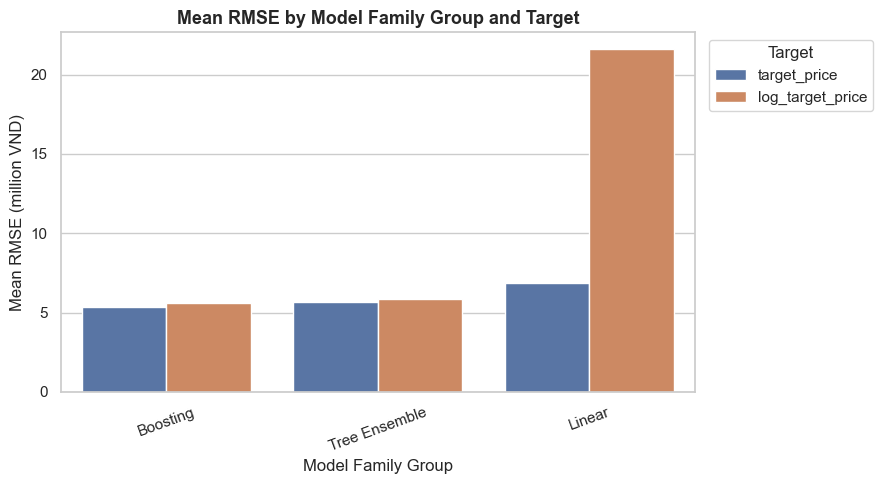

Saved: model_family_rmse_by_target.png


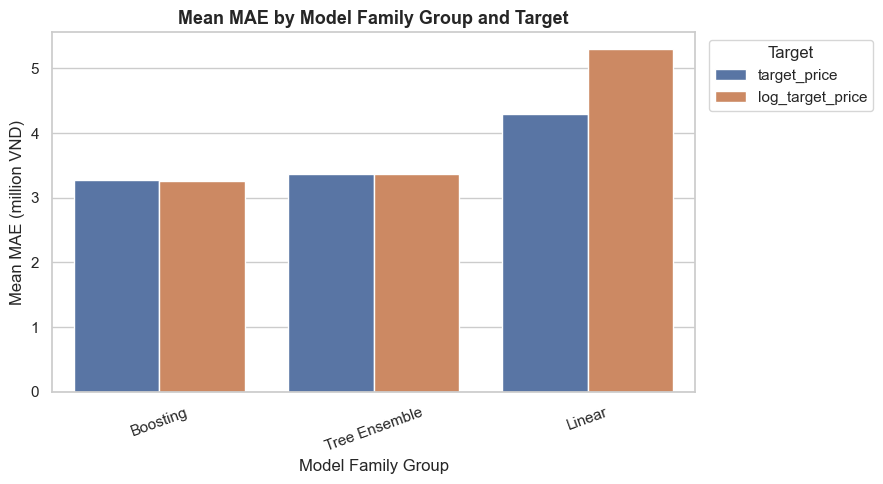

Saved: model_family_mae_by_target.png


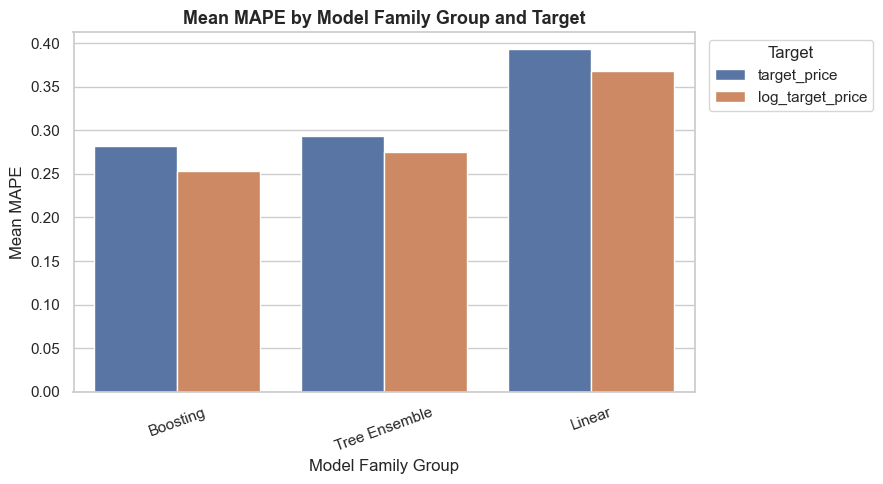

Saved: model_family_mape_by_target.png


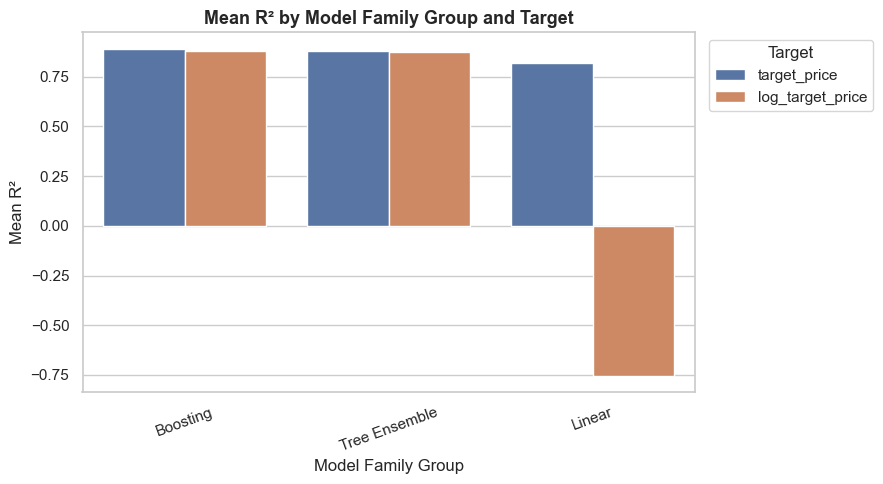

Saved: model_family_r2_by_target.png


In [24]:
# Prepare plot data
_plot_df = family_perf_df.copy()
_plot_df['target_used'] = pd.Categorical(
    _plot_df['target_used'],
    categories=TARGET_ORDER,
    ordered=True,
)

_family_order = ['Boosting', 'Tree Ensemble', 'Linear']
_existing_groups = [g for g in _family_order if g in _plot_df['model_family_group'].unique()]


def _family_bar_plot(metric_col, ylabel, title, filename, higher_is_better=False):
    fig, ax = plt.subplots(figsize=(9, 5))
    plot_df = _plot_df.sort_values(['model_family_group', 'target_used'])
    sns.barplot(
        data=plot_df,
        x='model_family_group',
        y=metric_col,
        hue='target_used',
        order=_existing_groups,
        hue_order=target_hue_order,
        palette=target_palette,
        ax=ax,
        errorbar=None,
    )
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Model Family Group')
    ax.set_ylabel(ylabel)
    ax.tick_params(axis='x', rotation=20)
    ax.legend(title='Target', bbox_to_anchor=(1.01, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig(COMPARISON_DIR / filename, dpi=160, bbox_inches='tight')
    plt.show()
    print(f'Saved: {filename}')


_family_bar_plot('rmse_mean', 'Mean RMSE (million VND)', 'Mean RMSE by Model Family Group and Target',
                 'model_family_rmse_by_target.png')
_family_bar_plot('mae_mean', 'Mean MAE (million VND)', 'Mean MAE by Model Family Group and Target',
                 'model_family_mae_by_target.png')
if 'mape_mean' in _plot_df.columns:
    _family_bar_plot('mape_mean', 'Mean MAPE', 'Mean MAPE by Model Family Group and Target',
                     'model_family_mape_by_target.png')
_family_bar_plot('r2_mean', 'Mean R²', 'Mean R² by Model Family Group and Target',
                 'model_family_r2_by_target.png', higher_is_better=True)


### Model Family Comparison Visualization Interpretation

The family-level plots confirm that Boosting models are best overall in numeric encoding.

For **RMSE** and **R²**, direct-price Boosting is the strongest family-target combination. Tree Ensembles follow, and Linear log-target models are clearly invalid because their R² is negative.

For **MAE**, Boosting remains best under both targets, with log-target slightly ahead on average. For **MAPE**, log-target improves all families, but this does not offset the RMSE/R² failure of linear log-target models.

Overall, the plots support tuning LightGBM and CatBoost first, prioritizing direct-price variants for balanced performance and retaining log-target variants for MAE/MAPE checks.


## 18. Fine-Tuning Candidate Selection

Based on the metrics analysis, pairwise comparison, segment-level results, and model family performance, we select the model-target combinations that should advance to the next hyperparameter tuning notebook.

In [25]:
# Build candidate table from the updated metric decision
candidates = [
    {
        'candidate_rank': 1,
        'model_name': 'LightGBM',
        'target_used': 'target_price',
        'reason_for_selection': 'Primary baseline for tuning: best RMSE and R², with MAE within the 2% close band of the best MAE result.',
        'priority': 'High',
        'tuning_status': 'Selected for tuning',
    },
    {
        'candidate_rank': 2,
        'model_name': 'LightGBM',
        'target_used': 'log_target_price',
        'reason_for_selection': 'Best MAE and best MAPE; key alternative if typical or relative error is prioritized over RMSE.',
        'priority': 'High',
        'tuning_status': 'Selected for tuning',
    },
    {
        'candidate_rank': 3,
        'model_name': 'CatBoost',
        'target_used': 'target_price',
        'reason_for_selection': 'Strong secondary boosting candidate: second-best RMSE/R² and stable price-scale behavior.',
        'priority': 'Medium-High',
        'tuning_status': 'Selected for tuning',
    },
    {
        'candidate_rank': 4,
        'model_name': 'CatBoost',
        'target_used': 'log_target_price',
        'reason_for_selection': 'Secondary log_target_price boosting check; improves MAPE but loses RMSE/R² versus target_price.',
        'priority': 'Medium',
        'tuning_status': 'Selected for tuning',
    },
    {
        'candidate_rank': 5,
        'model_name': 'Extra Trees',
        'target_used': 'log_target_price',
        'reason_for_selection': 'Optional diversity candidate; not a leading model under the updated numeric ranking.',
        'priority': 'Low',
        'tuning_status': 'Optional',
    }
]

excluded_models = [
    {
        'model_name': m,
        'target_used': 'target_price baseline only',
        'reason_excluded': (
            'Linear models are kept as baselines, not tuning candidates. '
            'Do not tune linear + log_target_price when it shows unstable price-scale behavior.'
        ),
        'tuning_status': 'Excluded',
    }
    for m in ['Linear Regression', 'Ridge', 'Lasso', 'ElasticNet']
]

candidates_df = pd.DataFrame(candidates)
print('=== Fine-Tuning Candidates ===')
display(candidates_df)

candidates_df.to_csv(COMPARISON_DIR / 'fine_tuning_candidates.csv', index=False)
print('Saved: fine_tuning_candidates.csv')

excluded_df = pd.DataFrame(excluded_models)
print('\n=== Excluded Models ===')
display(excluded_df)


=== Fine-Tuning Candidates ===


,candidate_rank,model_name,target_used,reason_for_selection,priority,tuning_status
0,1,LightGBM,target_price,"Primary baseline for tuning: best RMSE and R²,...",High,Selected for tuning
1,2,LightGBM,log_target_price,Best MAE and best MAPE; key alternative if typ...,High,Selected for tuning
2,3,CatBoost,target_price,Strong secondary boosting candidate: second-be...,Medium-High,Selected for tuning
3,4,CatBoost,log_target_price,Secondary log_target_price boosting check; imp...,Medium,Selected for tuning
4,5,Extra Trees,log_target_price,Optional diversity candidate; not a leading mo...,Low,Optional


Saved: fine_tuning_candidates.csv

=== Excluded Models ===


,model_name,target_used,reason_excluded,tuning_status
0,Linear Regression,target_price baseline only,"Linear models are kept as baselines, not tunin...",Excluded
1,Ridge,target_price baseline only,"Linear models are kept as baselines, not tunin...",Excluded
2,Lasso,target_price baseline only,"Linear models are kept as baselines, not tunin...",Excluded
3,ElasticNet,target_price baseline only,"Linear models are kept as baselines, not tunin...",Excluded


### Fine-Tuning Candidate Selection Interpretation

The updated numeric metrics favor **LightGBM** as the leading model family candidate rather than CatBoost.

**LightGBM with `target_price`** is the primary candidate because it is the best balanced model: best RMSE, best R², and MAE within 2% of the best MAE result.

**LightGBM with `log_target_price`** should also be tuned because it has the best MAE and MAPE. It is the key alternative if typical or relative error is prioritized.

**CatBoost with `target_price`** remains a strong secondary candidate because it ranks second by RMSE and R².

**CatBoost with `log_target_price`** can be kept as a secondary log-target check, but it is no longer the leading choice.

**Linear models** should be excluded from fine-tuning, especially their log-target variants, which fail under numeric encoding.


## 19. Recommended Fine-Tuning Strategy

### Tuning Order

1. **LightGBM + `target_price`** - Current best balanced model, with best RMSE and R² and near-best MAE.
2. **LightGBM + `log_target_price`** - Best MAE and MAPE; key alternative if typical or relative error is prioritized.
3. **CatBoost + `target_price`** - Strong second-best RMSE/R² candidate and useful robustness check against LightGBM.
4. **CatBoost + `log_target_price`** - Secondary log-target boosting comparison.
5. *(Optional)* **Extra Trees + `log_target_price`** - Optional model-diversity candidate, not a leading model under the updated ranking.

### Tuning Guidelines

- **Use cross-validation** during tuning rather than relying only on a single train/test split.
- **Evaluate on the original price scale.** For log-target models, inverse-transform predictions using `np.expm1()` before computing metrics.
- **Use MAE as the primary metric with RMSE as the close-result tiebreaker**, matching the notebook's final selection logic.
- **Do not tune log-target linear models** in numeric encoding; their RMSE and R² indicate failed configurations.
- **Track Premium-segment behavior**, because direct-price models can be better for high-price absolute errors.


## Notebook Summary

This notebook compared `target_price` and `log_target_price` strategies for laptop price prediction using **numeric feature encoding**. All predictions were evaluated on the original price scale.

**Key findings:**

- **Best RMSE and R²:** LightGBM with `target_price` (RMSE = 5.3365, R² = 0.8930).
- **Best MAE and MAPE:** LightGBM with `log_target_price` (MAE = 3.2178, MAPE = 0.2517).
- **Best balanced model:** LightGBM with `target_price` (MAE = 3.2246, RMSE = 5.3365), because the top MAE results are within 2% and RMSE is used as the tiebreaker.
- Direct `target_price` wins RMSE for all 8 models and has much better aggregate RMSE/R².
- `log_target_price` still wins MAPE for all models and wins MAE for strong boosting models, but it fails badly for linear numeric models.
- Recommended tuning focus: LightGBM `target_price`, LightGBM `log_target_price`, CatBoost `target_price`, CatBoost `log_target_price`; exclude log-target linear models.

Primary recommendation: **LightGBM with `target_price`** under the current MAE-primary plus RMSE-tiebreaker rule.


## 20. Save Final Recommendation Text File

We write a concise text summary of the target and model family decisions to `final_target_and_model_family_recommendation.txt`. This file is notebook-specific and should reflect the actual best RMSE, best MAE, and balanced candidate for this encoding.


In [26]:
# Write final recommendation text file
rec_lines_full = [
    'Final Target and Model Family Recommendation',
    '=' * 55,
    '',
    'Selected final candidate before tuning:',
    '  LightGBM + target_price',
    '',
    'Strong alternative:',
    '  LightGBM + log_target_price',
    '',
    'Models recommended for fine-tuning:',
    '  1. LightGBM    + target_price      [High priority, main baseline]',
'  2. LightGBM    + log_target_price  [High priority, best MAE/MAPE alternative]',
'  3. CatBoost    + target_price      [Medium-High, secondary boosting baseline]',
'  4. CatBoost    + log_target_price  [Medium, target-strategy check]',
'  5. Extra Trees + log_target_price  [Low, optional diversity]',
    '',
    'Models excluded from fine-tuning:',
    '  Linear Regression',
    '  Ridge',
    '  Lasso',
    '  ElasticNet',
    '',
    'Reason for exclusion:',
    '  Linear models are baseline/reference models, not production tuning candidates.',
    '  In numeric encoding, linear + log_target_price is unstable on the price scale',
    '  and should not be tuned unless a separate clipping/robustness experiment is added.',
    '',
    'Metric scale note:',
    '  The selected model is chosen from metrics evaluated on target_price scale.',
    '  MAE/RMSE/median absolute error/max error on target_price scale are in million VND.',
    '  Metrics on log_target_price scale are log-space diagnostics and are not directly',
    '  comparable to price-scale MAE/RMSE.',
    '',
    'Note on log_target_price:',
    '  log_target_price often improves MAE/MAPE, but it is not universally better.',
    '  For the strongest boosting models, target_price usually gives better RMSE and R2.',
    '  Keep both target strategies only where they answer different metric objectives.',
    '',
    'Baseline decision:',
    '  Use 08b numeric as the main baseline for the next tuning notebook; its top RMSE/R2 beat 08a.',
]

rec_full_text = '\n'.join(rec_lines_full)
rec_full_path = COMPARISON_DIR / 'final_target_and_model_family_recommendation.txt'
rec_full_path.write_text(rec_full_text, encoding='utf-8')

print(rec_full_text)
print(f'\nSaved: final_target_and_model_family_recommendation.txt')


Final Target and Model Family Recommendation

Selected final candidate before tuning:
  LightGBM + target_price

Strong alternative:
  LightGBM + log_target_price

Models recommended for fine-tuning:
  1. LightGBM    + target_price      [High priority, main baseline]
  2. LightGBM    + log_target_price  [High priority, best MAE/MAPE alternative]
  3. CatBoost    + target_price      [Medium-High, secondary boosting baseline]
  4. CatBoost    + log_target_price  [Medium, target-strategy check]
  5. Extra Trees + log_target_price  [Low, optional diversity]

Models excluded from fine-tuning:
  Linear Regression
  Ridge
  Lasso
  ElasticNet

Reason for exclusion:
  Linear models are baseline/reference models, not production tuning candidates.
  In numeric encoding, linear + log_target_price is unstable on the price scale
  and should not be tuned unless a separate clipping/robustness experiment is added.

Metric scale note:
  The selected model is chosen from metrics evaluated on target_pri

## 14. Save Final Outputs

In [27]:
# Write final recommendation text
rec_lines = [
    'Final Model and Target Recommendation',
    '=' * 50,
    '',
    f'Best model by RMSE : {best_rmse_row["model_name"]} ({best_rmse_row["target_used"]})',
    f'  RMSE = {best_rmse_row["rmse"]:,.4f}',
    f'  MAE  = {best_rmse_row["mae"]:,.4f}',
    f'  R2   = {best_rmse_row["r2"]:,.4f}',
    '',
    f'Best model by MAE  : {best_mae_row["model_name"]} ({best_mae_row["target_used"]})',
    f'  MAE  = {best_mae_row["mae"]:,.4f}',
    f'  RMSE = {best_mae_row["rmse"]:,.4f}',
    f'  R2   = {best_mae_row["r2"]:,.4f}',
    '',
    f'Best balanced model: {best_balanced_row["model_name"]} ({best_balanced_row["target_used"]})',
    f'  MAE  = {best_balanced_row["mae"]:,.4f}',
    f'  RMSE = {best_balanced_row["rmse"]:,.4f}',
    f'  R2   = {best_balanced_row["r2"]:,.4f}',
    f'  ({tiebreak_note})',
    '',
]

if not pairwise_df.empty:
    rec_lines += [
        f'log_target_price wins RMSE: {n_models_log_wins_rmse}/{total_paired} models'
        f'  (weighted: {log_weighted_rmse:.2f}/{total_weight:.2f})',
        f'log_target_price wins MAE : {n_models_log_wins_mae}/{total_paired} models'
        f'  (weighted: {log_weighted_mae:.2f}/{total_weight:.2f})',
        '',
    ]

rec_lines += [
    'Decision rule     : MAE is primary; RMSE and R2 break close MAE ties.',
    'Metric scale      : final selection uses target_price-scale metrics only.',
    'Price-scale units : MAE/RMSE/median absolute error/max error are million VND.',
    'Log-scale metrics : diagnostic only; do not compare directly with price-scale metrics.',
    'Target note       : log_target_price may reduce MAE/MAPE, but target_price is stronger when RMSE/R2 are prioritized.',
    f'Close-win threshold: {CLOSE_WIN_THRESHOLD*100:.0f}%',
]

rec_text = '\n'.join(rec_lines)
rec_path = COMPARISON_DIR / 'final_model_target_recommendation.txt'
rec_path.write_text(rec_text, encoding='utf-8')
print(rec_text)
print(f'\nSaved: final_model_target_recommendation.txt')


Final Model and Target Recommendation

Best model by RMSE : LightGBM (target_price)
  RMSE = 5.3365
  MAE  = 3.2246
  R2   = 0.8930

Best model by MAE  : LightGBM (log_target_price)
  MAE  = 3.2178
  RMSE = 5.5069
  R2   = 0.8860

Best balanced model: LightGBM (target_price)
  MAE  = 3.2246
  RMSE = 5.3365
  R2   = 0.8930
  (2 MAE-leading results are within 2%; RMSE then R² used as tiebreakers.)

log_target_price wins RMSE: 0/8 models  (weighted: 0.00/4.50)
log_target_price wins MAE : 3/8 models  (weighted: 2.50/4.50)

Decision rule     : MAE is primary; RMSE and R2 break close MAE ties.
Metric scale      : final selection uses target_price-scale metrics only.
Price-scale units : MAE/RMSE/median absolute error/max error are million VND.
Log-scale metrics : diagnostic only; do not compare directly with price-scale metrics.
Target note       : log_target_price may reduce MAE/MAPE, but target_price is stronger when RMSE/R2 are prioritized.
Close-win threshold: 2%

Saved: final_model_targe

In [28]:
# ── Summary of saved artifacts ────────────────────────────────────────────────
print('=== Artifacts saved to', COMPARISON_DIR, '===')
for f in sorted(COMPARISON_DIR.iterdir()):
    size_kb = f.stat().st_size / 1024
    print(f'  {f.name:<55}  {size_kb:6.1f} KB')

=== Artifacts saved to Y:\Python\Laptop-Price-Prediction\artifacts\modeling_numeric\target_comparison ===
  diagnostic_CatBoost_log_target_price.png                  203.7 KB
  diagnostic_CatBoost_target_price.png                      203.5 KB
  diagnostic_LightGBM_log_target_price.png                  209.2 KB
  diagnostic_LightGBM_target_price.png                      215.8 KB
  final_model_target_recommendation.txt                       1.0 KB
  final_target_and_model_family_recommendation.txt            1.7 KB
  fine_tuning_candidates.csv                                  0.8 KB
  linear_log_target_outlier_check.csv                         3.5 KB
  mae_by_model_and_target.png                                71.2 KB
  mape_by_model_and_target.png                               74.1 KB
  model_family_mae_by_target.png                             48.9 KB
  model_family_mape_by_target.png                            55.1 KB
  model_family_metrics.csv                                    2.0 